In [1]:
import os
import zipfile

import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

import matplotlib.pyplot as plt

from typing import Union, Dict

In [57]:
# stop warning messages
import warnings
warnings.filterwarnings('ignore')

### Loading Zacks Fundamentals Data

In [2]:
# Reading Data
data_dir = r'data/ZacksFundamentalsB'
zip_files = [f for f in os.listdir(data_dir) if f.endswith('.zip')]
data = {}
for zip_file in zip_files:
    with zipfile.ZipFile(os.path.join(data_dir, zip_file), 'r') as z:
        for file_name in z.namelist():
            if file_name.endswith('.csv'):
                with z.open(file_name) as f:
                    df = pd.read_csv(f)
                    data[zip_file.split('_')[0]] = df

                    print(f'Read file: {'_'.join(file_name.split('_')[:2])} from {zip_file} with shape {df.shape}')

C:\Users\daddy\AppData\Local\Temp\ipykernel_1900\2422175044.py:10: DtypeWarning: Columns (0: exchange, 1: comp_cik, 2: per_len, 3: sic_code, 4: filing_date, 5: last_changed_date, 6: state_incorp_name, 7: bus_address_line_1, 8: bus_city, 9: bus_state_name, 10: bus_post_code, 11: bus_phone_nbr, 12: bus_fax_nbr, 13: mail_address_line_1, 14: mail_city, 15: mail_state_name, 16: mail_post_code, 17: country_name, 18: country_code, 19: home_exchange_name, 20: auditor, 21: auditor_opinion, 22: comp_url, 23: email_addr, 24: shares_out_date, 25: officer_name_1, 26: officer_title_1, 27: officer_name_2, 28: officer_title_2, 29: officer_name_3, 30: officer_title_3, 31: officer_name_4, 32: officer_title_4, 33: officer_name_5, 34: officer_title_5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


Read file: ZACKS_FC from FC_20240123.zip with shape (649883, 249)


C:\Users\daddy\AppData\Local\Temp\ipykernel_1900\2422175044.py:10: DtypeWarning: Columns (0: exchange) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


Read file: ZACKS_FR from FR_20240123.zip with shape (649883, 40)
Read file: ZACKS_HDM from HDM_20240123.zip with shape (67004, 9)
Read file: ZACKS_MKTV from MKTV_20240123.zip with shape (1058327, 9)


C:\Users\daddy\AppData\Local\Temp\ipykernel_1900\2422175044.py:10: DtypeWarning: Columns (0: comp_cik) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


Read file: ZACKS_MT from MT_20240123.zip with shape (38868, 27)
Read file: QUOTEMEDIA_PRICES from PRICES_20241105.zip with shape (50508040, 14)
Read file: ZACKS_SHRS from SHRS_20240123.zip with shape (1058399, 9)
Read file: QUOTEMEDIA_TICKERS from TICKERS_20240123.zip with shape (21912, 3)


In [3]:
data.keys()

dict_keys(['FC', 'FR', 'HDM', 'MKTV', 'MT', 'PRICES', 'SHRS', 'TICKERS'])

### Universe Selection

Choose at least 200 tickers of US equities such that they satisfy the following:
- end-of-day adjusted closing prices are available , over the entire period Jan 2018 through Jun 2023
- the market value (as reported in MKTV2) never dips below $100MM, over the entire period Jan 2018 through Jun 2023
- debt/market cap ratio is greater than 0.1 somewhere in the period Jan 2018 through Jun 2023 (preferably more than fleetingly)
- not in the automotive, financial or insurance sector , over the entire period Jan 2018 through Jun 2023
- has feasible calculation of the ratios specified below , over the entire period Jan 2018 through Jun 2023, including for at least one per end date no more than one year old. A debt ratio of zero is OK.

In [8]:
data_fc = data['FC'].copy()
data_fr = data['FR'].copy()
data_mktv = data['MKTV'].copy()
data_mt = data['MT'].copy()
data_shrs = data['SHRS'].copy()

In [9]:
# Fundamentals Condensed
data_fc = data_fc[['ticker','per_end_date','filing_date','per_type','per_fisc_qtr','net_lterm_debt','tot_lterm_debt','eps_diluted_net','basic_net_eps']]

# Fundamentals Ratios
data_fr = data_fr[['ticker','per_end_date','per_type','per_fisc_qtr','tot_debt_tot_equity','ret_invst']]

# Market Value
data_mktv = data_mktv[['ticker','per_end_date','mkt_val']]

# Shares Out
data_shrs = data_shrs[['ticker','per_end_date','shares_out']]

# Master Table
data_mt = data_mt[['ticker','asset_type','zacks_x_sector_code','active_ticker_flag']].drop_duplicates()


#### Filtering Master Table Data
- Selecting US Equities
- Filtering out Auto-Tires-Trucks - 5, Financial - 13
- Keeping only active tickers

In [10]:
# Selecting US Equities
data_mt = data_mt.loc[data_mt['asset_type']=='COM']

# Filtering out Auto-Tires-Trucks - 5, Financial - 13
tickers_to_remove = data_mt.loc[data_mt['zacks_x_sector_code'].isin([5,13]), 'ticker'].unique().tolist()
data_mt = data_mt.loc[~data_mt['ticker'].isin(tickers_to_remove)]

# Keeping only active tickers
data_mt = data_mt.loc[data_mt['active_ticker_flag']=='Y']

# Intermediate list of tickers to keep
tickers_to_keep = data_mt['ticker'].unique().tolist()

#### Filtering Market Value Data
- Selecting only those whose market value never drops below $100M over the period Jan 2018 to Jun 2023

In [11]:
# Filtering data based on selected tickers and date range
data_mktv = data_mktv.loc[data_mktv['ticker'].isin(tickers_to_keep)]
data_mktv['per_end_date'] = pd.to_datetime(data_mktv['per_end_date'])
data_mktv = data_mktv.set_index('per_end_date').sort_index().loc['2017-07-01':'2024-01-01'].reset_index()

# Selecting only those whose market value never drops below $100M over the period Jan 2018 to Jun 2023
data_mktv['above_mkt_cap_threshold'] = data_mktv.groupby('ticker')['mkt_val'].transform(lambda x: np.all(x>100)).fillna(False)
data_mktv = data_mktv.loc[data_mktv['above_mkt_cap_threshold']]

data_mktv.drop('above_mkt_cap_threshold', axis=1, inplace=True)

# Final list of tickers to keep
tickers_to_keep = data_mktv['ticker'].unique().tolist()

#### Filtering Fundamentals Condensed Data
- Removing annual 10-K entries if Q4 exists for the same ticker and per_end_date
- Selecting only those tickers which have data in the whole date range
- Filter out tickers which have missing filing_date
- Filter out tickers which have missing lterm_debt_syn
- Filter out tickers which have missing eps_diluted_syn
- Remove duplicated ticker and filing date and keep the latest per_end_date

In [12]:
# Filtering data based on selected tickers and date range
data_fc = data_fc.loc[data_fc['ticker'].isin(tickers_to_keep)]

# Removing annual 10-K entries if Q4 exists for the same ticker and per_end_date
q4 = data_fc.loc[(data_fc['per_type']=='Q') & (data_fc['per_fisc_qtr']==4), ['ticker', 'per_end_date']]
annual = data_fc.loc[(data_fc['per_type']=='A'), ['ticker', 'per_end_date']]
merged = pd.merge(annual, q4, on=['ticker','per_end_date'], how='left', indicator=True)
annual_with_q4 = merged.loc[merged['_merge']=='both', ['ticker', 'per_end_date']]
data_fc = pd.merge(data_fc, annual_with_q4, on=['ticker','per_end_date'], how='left', indicator=True)
data_fc = data_fc.loc[~((data_fc['per_type']=='A') & (data_fc['_merge']=='both'))]
data_fc.drop('_merge', axis=1, inplace=True)

data_fc['per_end_date'] = pd.to_datetime(data_fc['per_end_date'])
data_fc = data_fc.set_index('per_end_date').sort_index().loc['2017-07-01':'2024-01-01'].reset_index()
data_fc['filing_date'] = pd.to_datetime(data_fc['filing_date'])

# Filter out tickers which have missing filing_date
tickers_to_remove = data_fc.loc[data_fc['filing_date'].isna(), 'ticker'].unique().tolist()
data_fc = data_fc.loc[~data_fc['ticker'].isin(tickers_to_remove)]

# Keep only tickers with data in the whole date range
min_report_date = data_fc.groupby('ticker')['per_end_date'].min().reset_index()
max_report_date = data_fc.groupby('ticker')['per_end_date'].max().reset_index()
tickers_to_keep_min = min_report_date.loc[min_report_date['per_end_date'] <= pd.Timestamp('2018-01-01'), 'ticker'].unique().tolist()
tickers_to_keep_max = max_report_date.loc[max_report_date['per_end_date'] >= pd.Timestamp('2023-06-30'), 'ticker'].unique().tolist()
tickers_to_keep = list(set(tickers_to_keep_min) & set(tickers_to_keep_max))
data_fc = data_fc.loc[data_fc['ticker'].isin(tickers_to_keep)]

# Creating lterm_debt_syn by prioritizing net_lterm_debt over tot_lterm_debt
data_fc['lterm_debt_syn'] = data_fc['net_lterm_debt'].fillna(data_fc['tot_lterm_debt'])

# Filter out tickers which have missing lterm_debt_syn
tickers_to_remove = data_fc.loc[data_fc['lterm_debt_syn'].isna(), 'ticker'].unique().tolist()
data_fc = data_fc.loc[~data_fc['ticker'].isin(tickers_to_remove)]

# Creating eps_diluted_syn by prioritizing eps_diluted_net over basic_net_eps and filling negatives with 0.001
data_fc['eps_diluted_syn'] = data_fc['eps_diluted_net'].fillna(data_fc['basic_net_eps'])
data_fc.loc[data_fc['eps_diluted_syn']<=0, 'eps_diluted_syn'] = 0.001

# Filter out tickers which have missing eps_diluted_syn
tickers_to_remove = data_fc.loc[data_fc['eps_diluted_syn'].isna(), 'ticker'].unique().tolist()
data_fc = data_fc.loc[~data_fc['ticker'].isin(tickers_to_remove)]

data_fc.drop(['per_type','per_fisc_qtr','net_lterm_debt','tot_lterm_debt','eps_diluted_net','basic_net_eps'], axis=1, inplace=True)

# Remove duplicated ticker and filing date and keep the latest per_end_date
data_fc.sort_values(by=['ticker','filing_date','per_end_date'], inplace=True)
data_fc = data_fc.drop_duplicates(subset=['ticker','filing_date'], keep='last')

display(data_fc.head())

,per_end_date,ticker,filing_date,lterm_debt_syn,eps_diluted_syn
69,2017-07-31,A,2017-09-06,1801.0,0.540
1708,2017-10-31,A,2017-12-21,110.0,0.540
3216,2018-01-31,A,2018-03-06,1800.0,0.001
4875,2018-04-30,A,2018-05-31,-251.0,0.630
6412,2018-07-31,A,2018-08-30,1799.0,0.730


#### Filtering Fundamentals Ratios Data
- Removing annual 10-K entries if Q4 exists for the same ticker and per_end_date
- Keeping only those tickers which have at least one per_end_date no more than 1 year old
- Selecting only those tickers which have data in the whole date range
- Filter out tickers which have missing tot_debt_tot_equity or ret_invst

In [13]:
# Filtering data based on selected tickers and date range
data_fr = data_fr.loc[data_fr['ticker'].isin(tickers_to_keep)]

# Removing annual 10-K entries if Q4 exists for the same ticker and per_end_date
q4 = data_fr.loc[(data_fr['per_type']=='Q') & (data_fr['per_fisc_qtr']==4), ['ticker', 'per_end_date']]
annual = data_fr.loc[(data_fr['per_type']=='A'), ['ticker', 'per_end_date']]
merged = pd.merge(annual, q4, on=['ticker','per_end_date'], how='left', indicator=True)
annual_with_q4 = merged.loc[merged['_merge']=='both', ['ticker', 'per_end_date']]
data_fr = pd.merge(data_fr, annual_with_q4, on=['ticker','per_end_date'], how='left', indicator=True)
data_fr = data_fr.loc[~((data_fr['per_type']=='A') & (data_fr['_merge']=='both'))]
data_fr.drop('_merge', axis=1, inplace=True)

data_fr['per_end_date'] = pd.to_datetime(data_fr['per_end_date'])
data_fr = data_fr.set_index('per_end_date').sort_index().loc['2017-07-01':'2024-01-01'].reset_index()

# Filter out tickers which have missing tot_debt_tot_equity or ret_invst
tickers_to_remove = data_fr.loc[data_fr['tot_debt_tot_equity'].isna() | data_fr['ret_invst'].isna(), 'ticker'].unique().tolist()
data_fr = data_fr.loc[~data_fr['ticker'].isin(tickers_to_remove)]

# Keeping only those tickers which have at least one per_end_date no more than 1 year old
max_diff_in_report = data_fr.groupby(['ticker'])['per_end_date'].apply(lambda x: np.diff(x).max()).dt.days.reset_index()
tickers_to_keep = max_diff_in_report.loc[max_diff_in_report['per_end_date'] < 365, 'ticker'].unique().tolist()
data_fr = data_fr.loc[data_fr['ticker'].isin(tickers_to_keep)]

# Keep only tickers with data in the whole date range
min_report_date = data_fr.groupby('ticker')['per_end_date'].min().reset_index()
max_report_date = data_fr.groupby('ticker')['per_end_date'].max().reset_index()
tickers_to_keep_min = min_report_date.loc[min_report_date['per_end_date'] <= pd.Timestamp('2018-01-01'), 'ticker'].unique().tolist()
tickers_to_keep_max = max_report_date.loc[max_report_date['per_end_date'] >= pd.Timestamp('2023-06-30'), 'ticker'].unique().tolist()
tickers_to_keep = list(set(tickers_to_keep_min) & set(tickers_to_keep_max) & set(tickers_to_keep))
data_fr = data_fr.loc[data_fr['ticker'].isin(tickers_to_keep)]

data_fr.drop(['per_type','per_fisc_qtr'], axis=1, inplace=True)

display(data_fr.head())

,per_end_date,ticker,tot_debt_tot_equity,ret_invst
0,2017-07-31,OLLI,0.1841,2.4118
1,2017-07-31,DLTR,0.9831,2.0410
2,2017-07-31,PANW,0.6908,-1.9154
3,2017-07-31,CAL,0.3622,2.1080
4,2017-07-31,SWBI,0.6160,-0.3937


#### Filtering Shares Out Data
- Filter out tickers which have missing shares_out

In [14]:
data_shrs = data_shrs.loc[data_shrs['ticker'].isin(tickers_to_keep)]
data_shrs['per_end_date'] = pd.to_datetime(data_shrs['per_end_date'])
data_shrs = data_shrs.set_index('per_end_date').sort_index().loc['2017-07-01':'2024-01-01'].reset_index()

# Filter out tickers which have missing shares_out
tickers_to_remove = data_shrs.loc[data_shrs['shares_out'].isna(), 'ticker'].unique().tolist()
data_shrs = data_shrs.loc[~data_shrs['ticker'].isin(tickers_to_remove)]

display(data_shrs.head())

,per_end_date,ticker,shares_out
0,2017-07-31,CPB,303.07
1,2017-07-31,HIBB,20.77
2,2017-07-31,TJX,1272.55
3,2017-07-31,SMTC,66.20
4,2017-07-31,MTN,40.01


### Combining Filtered Zack's Fundamental Data

In [15]:
# Combining data
df = data_fr.copy()

df.sort_values(by=['ticker','per_end_date'], inplace=True)

df = pd.merge(df, data_fc, on=['ticker','per_end_date'], how='inner')

# Shares outstanding and Market Value
df_shrs_mktv = pd.merge(data_shrs, data_mktv, on=['ticker','per_end_date'], how='inner')

df = pd.merge(df, df_shrs_mktv, on=['ticker','per_end_date'], how='outer', indicator=True)

df = df.loc[df['per_end_date']!=pd.Timestamp('2023-12-31')]

# Dropping tickers which do not have complete data across all datasets
tickers_to_drop = df.loc[df['_merge']!='both', 'ticker'].unique().tolist()

df = df.loc[~df['ticker'].isin(tickers_to_drop)]
df.drop('_merge', axis=1, inplace=True)

# Adding 1 to filing_date to represent the date we actually get the financial data
df['date'] = df['filing_date'] + pd.Timedelta(days=1)

base_cols = ['ticker','per_end_date','filing_date','date']
value_cols = [col for col in df.columns if col not in base_cols]
rename = {col:f'{col}_per_end' for col in value_cols}
df.rename(columns=rename, inplace=True)

value_cols = [f'{col}_per_end' for col in value_cols]

df = df[base_cols + value_cols]

display(df)

,ticker,per_end_date,filing_date,date,tot_debt_tot_equity_per_end,ret_invst_per_end,lterm_debt_syn_per_end,eps_diluted_syn_per_end,shares_out_per_end,mkt_val_per_end
26,AA,2017-09-30,2017-10-27,2017-10-28,0.1726,1.7786,-52.0,0.600,185.02,8625.77
27,AA,2017-12-31,2018-02-26,2018-02-27,0.2065,-0.0855,-39.0,0.001,185.20,9976.78
28,AA,2018-03-31,2018-05-09,2018-05-10,0.1942,3.7938,57.0,1.040,186.18,8370.47
29,AA,2018-06-30,2018-08-02,2018-08-03,0.2714,1.4517,546.0,0.050,186.47,8741.85
30,AA,2018-09-30,2018-11-02,2018-11-03,0.2504,2.1417,448.0,0.001,186.49,7534.36
...,...,...,...,...,...,...,...,...,...,...
27960,ZTS,2022-09-30,2022-11-03,2022-11-04,1.4078,5.3485,5210.0,1.130,466.07,69113.81
27961,ZTS,2022-12-31,2023-02-14,2023-02-15,1.7951,4.1990,1348.0,0.980,466.07,68302.85
27962,ZTS,2023-03-31,2023-05-04,2023-05-05,1.4611,4.9864,-1350.0,1.190,462.11,76913.95
27963,ZTS,2023-06-30,2023-08-08,2023-08-09,1.4190,5.9950,-1350.0,1.450,462.11,79580.33


### Loading Daily Price (Adj Close) Data

In [16]:
# Daily Price Data
data_prices = data['PRICES'].copy()

data_prices = data_prices[['ticker','date','adj_close']]
data_prices = data_prices.loc[data_prices['ticker'].isin(df['ticker'].unique().tolist())]
data_prices['date'] = pd.to_datetime(data_prices['date'])
data_prices = data_prices.set_index('date').sort_index().loc['2017-07-01':'2024-01-01'].reset_index()

data_prices = data_prices.dropna()

display(data_prices.head())

,date,ticker,adj_close
0,2017-07-03,JNJ,109.869693
1,2017-07-03,CHRS,14.650000
2,2017-07-03,EL,88.909246
3,2017-07-03,MRC,16.800000
4,2017-07-03,ALLE,74.314982


### Combining Financial and Price Data

#### Combining with price data based on per_end_date to get share price at the end of financial period

In [17]:
# Combining with price data based on per_end_date to get share price at the end of financial period
data_prices_per_end = data_prices.rename(columns={'date':'per_end_date','adj_close':'adj_close_per_end'})

df_per_end_price = pd.merge(df[['ticker','per_end_date']], data_prices_per_end, on=['ticker','per_end_date'], how='outer')

df_per_end_price.sort_values(by=['ticker','per_end_date'], inplace=True)

# Forward fill to get latest financials for each date
df_per_end_price = df_per_end_price.groupby('ticker').apply(lambda g: g.ffill()).reset_index().drop('level_1', axis=1)

# Remove tickers which have missing adj_close_per_end
tickers_to_remove = df_per_end_price.loc[df_per_end_price['adj_close_per_end'].isna(), 'ticker'].unique().tolist()
df_per_end_price = df_per_end_price.loc[~df_per_end_price['ticker'].isin(tickers_to_remove)]

# Filtering to only those per_end_date which are present in df
df_per_end_price = pd.merge(df[['ticker','per_end_date']], df_per_end_price, on=['ticker','per_end_date'], how='inner')

display(df_per_end_price)

,ticker,per_end_date,adj_close_per_end
0,AA,2017-09-30,45.122666
1,AA,2017-12-31,52.139811
2,AA,2018-03-31,43.515981
3,AA,2018-06-30,45.374315
4,AA,2018-09-30,39.102439
...,...,...,...
22320,ZTS,2022-09-30,145.195900
22321,ZTS,2022-12-31,143.801497
22322,ZTS,2023-03-31,163.696634
22323,ZTS,2023-06-30,169.735717


#### Combining with price data based on (filing date + 1) as this is the date we actually get the financial data

In [18]:
# Combining with price data based on (filing date + 1) as this is the date we actually get the financial data
df_full = pd.merge(df, data_prices, on=['ticker','date'], how='outer')

# Create a full date range for each ticker
tickers = df_full['ticker'].unique().tolist()
dates = df_full['date'].unique().tolist()
full_date_range = pd.DataFrame([(ticker, date) for ticker in tickers for date in dates], columns=['ticker','date'])
df_full = pd.merge(full_date_range, df_full, on=['ticker','date'], how='left')

df_full.sort_values(by=['ticker','date'], inplace=True)

# Forward fill to get latest financials for each date
df_full = df_full.groupby('ticker').apply(lambda g: g.ffill()).reset_index().drop('level_1', axis=1)

# Adding adjusted close price at per_end_date
df_full = pd.merge(df_full, df_per_end_price, on=['ticker','per_end_date'], how='left')

df_full = df_full.set_index('date').sort_index().loc['2018-01-01':'2023-07-01'].reset_index()
df_full.dropna(inplace=True)

print('Tickers selected:', df_full['ticker'].nunique())
display(df_full)

Tickers selected: 893


,date,ticker,per_end_date,filing_date,tot_debt_tot_equity_per_end,ret_invst_per_end,lterm_debt_syn_per_end,eps_diluted_syn_per_end,shares_out_per_end,mkt_val_per_end,adj_close,adj_close_per_end
0,2018-01-02,FN,2017-09-30,2017-11-07,0.0962,2.8901,-3.495,0.550,37.58,1392.54,29.100000,37.060000
1,2018-01-02,MAS,2017-09-30,2017-10-24,51.4333,5.4143,2969.000,0.480,314.57,12271.18,39.698246,35.253929
2,2018-01-02,ANGI,2017-09-30,2017-11-09,0.0761,-6.4221,26.466,0.001,476.05,5931.52,11.420000,12.460000
3,2018-01-02,IQV,2017-09-30,2017-10-27,1.2993,0.5420,2384.000,0.400,211.31,20089.62,99.760000,95.070000
4,2018-01-02,WOLF,2017-09-30,2017-10-18,0.0636,-0.8432,-4.000,0.001,98.14,2766.43,38.140000,28.190000
...,...,...,...,...,...,...,...,...,...,...,...,...
1424539,2023-06-30,EVH,2023-03-31,2023-05-04,0.4892,-1.0382,218.830,0.001,112.67,3656.07,30.300000,32.450000
1424540,2023-06-30,SIX,2023-03-31,2023-05-08,-2.4115,-5.5219,70.000,0.001,83.28,2224.39,24.833493,25.531278
1424541,2023-06-30,FIVN,2023-03-31,2023-05-04,2.1807,-2.5268,739.284,0.001,71.54,5171.62,82.450000,72.290000
1424542,2023-06-30,KE,2023-03-31,2023-05-05,0.5752,2.2217,108.665,0.650,24.72,595.85,27.630000,24.100000


#### Calculating Required Ratios over the full date range

In [19]:
df_full['mkt_val'] = df_full['mkt_val_per_end'] * (df_full['adj_close'] / df_full['adj_close_per_end'])

df_full['tot_debt_tot_equity'] = (df_full['tot_debt_tot_equity_per_end'] * df_full['mkt_val_per_end']) / df_full['mkt_val']

df_full['return_per_end'] = df_full['ret_invst_per_end'] * (df_full['lterm_debt_syn_per_end'] + df_full['mkt_val_per_end'])
df_full['ret_invst'] =  df_full['return_per_end'] / (df_full['lterm_debt_syn_per_end'] + df_full['mkt_val'])

df_full['price_earnings'] = df_full['mkt_val'] / (df_full['shares_out_per_end'] * df_full['eps_diluted_syn_per_end'])

display(df_full)

,date,ticker,per_end_date,filing_date,tot_debt_tot_equity_per_end,ret_invst_per_end,lterm_debt_syn_per_end,eps_diluted_syn_per_end,shares_out_per_end,mkt_val_per_end,adj_close,adj_close_per_end,mkt_val,tot_debt_tot_equity,return_per_end,ret_invst,price_earnings
0,2018-01-02,FN,2017-09-30,2017-11-07,0.0962,2.8901,-3.495,0.550,37.58,1392.54,29.100000,37.060000,1093.440745,0.122515,4014.478954,3.683192,52.902450
1,2018-01-02,MAS,2017-09-30,2017-10-24,51.4333,5.4143,2969.000,0.480,314.57,12271.18,39.698246,35.253929,13818.156844,45.675215,82514.906574,4.915359,91.514851
2,2018-01-02,ANGI,2017-09-30,2017-11-09,0.0761,-6.4221,26.466,0.001,476.05,5931.52,11.420000,12.460000,5436.433258,0.083030,-38262.781891,-7.004116,11419.878707
3,2018-01-02,IQV,2017-09-30,2017-10-27,1.2993,0.5420,2384.000,0.400,211.31,20089.62,99.760000,95.070000,21080.682562,1.238216,12180.702040,0.519108,249.404696
4,2018-01-02,WOLF,2017-09-30,2017-10-18,0.0636,-0.8432,-4.000,0.001,98.14,2766.43,38.140000,28.190000,3742.874785,0.047008,-2329.280976,-0.622990,38138.116827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1424539,2023-06-30,EVH,2023-03-31,2023-05-04,0.4892,-1.0382,218.830,0.001,112.67,3656.07,30.300000,32.450000,3413.834237,0.523912,-4022.921180,-1.107430,30299.407449
1424540,2023-06-30,SIX,2023-03-31,2023-05-08,-2.4115,-5.5219,70.000,0.001,83.28,2224.39,24.833493,25.531278,2163.596114,-2.479260,-12669.392141,-5.672195,25979.780425
1424541,2023-06-30,FIVN,2023-03-31,2023-05-04,2.1807,-2.5268,739.284,0.001,71.54,5171.62,82.450000,72.290000,5898.465472,1.911981,-14935.672227,-2.250111,82449.894778
1424542,2023-06-30,KE,2023-03-31,2023-05-05,0.5752,2.2217,108.665,0.650,24.72,595.85,27.630000,24.100000,683.125954,0.501713,1565.220975,1.976811,42.514685


In [20]:
# Keep tickers which have debt/market cap ratio > 0.1 somewhere in the period Jan 2018 to Jun 2023
tickers_to_keep = df_full.loc[df_full['tot_debt_tot_equity']>0.1, 'ticker'].unique().tolist()
df_full = df_full.loc[df_full['ticker'].isin(tickers_to_keep)]

print('Final tickers selected:', df_full['ticker'].nunique())
display(df_full)

Final tickers selected: 865


,date,ticker,per_end_date,filing_date,tot_debt_tot_equity_per_end,ret_invst_per_end,lterm_debt_syn_per_end,eps_diluted_syn_per_end,shares_out_per_end,mkt_val_per_end,adj_close,adj_close_per_end,mkt_val,tot_debt_tot_equity,return_per_end,ret_invst,price_earnings
0,2018-01-02,FN,2017-09-30,2017-11-07,0.0962,2.8901,-3.495,0.550,37.58,1392.54,29.100000,37.060000,1093.440745,0.122515,4014.478954,3.683192,52.902450
1,2018-01-02,MAS,2017-09-30,2017-10-24,51.4333,5.4143,2969.000,0.480,314.57,12271.18,39.698246,35.253929,13818.156844,45.675215,82514.906574,4.915359,91.514851
2,2018-01-02,ANGI,2017-09-30,2017-11-09,0.0761,-6.4221,26.466,0.001,476.05,5931.52,11.420000,12.460000,5436.433258,0.083030,-38262.781891,-7.004116,11419.878707
3,2018-01-02,IQV,2017-09-30,2017-10-27,1.2993,0.5420,2384.000,0.400,211.31,20089.62,99.760000,95.070000,21080.682562,1.238216,12180.702040,0.519108,249.404696
4,2018-01-02,WOLF,2017-09-30,2017-10-18,0.0636,-0.8432,-4.000,0.001,98.14,2766.43,38.140000,28.190000,3742.874785,0.047008,-2329.280976,-0.622990,38138.116827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1424538,2023-06-30,ARMK,2023-03-31,2023-05-09,2.5185,0.5039,517.916,0.210,260.61,9329.79,42.412014,35.167226,11251.816741,2.088292,4962.259053,0.421612,205.594872
1424539,2023-06-30,EVH,2023-03-31,2023-05-04,0.4892,-1.0382,218.830,0.001,112.67,3656.07,30.300000,32.450000,3413.834237,0.523912,-4022.921180,-1.107430,30299.407449
1424541,2023-06-30,FIVN,2023-03-31,2023-05-04,2.1807,-2.5268,739.284,0.001,71.54,5171.62,82.450000,72.290000,5898.465472,1.911981,-14935.672227,-2.250111,82449.894778
1424542,2023-06-30,KE,2023-03-31,2023-05-05,0.5752,2.2217,108.665,0.650,24.72,595.85,27.630000,24.100000,683.125954,0.501713,1565.220975,1.976811,42.514685


### Loading LIBOR-SOFR Rate Data

In [21]:
# Read .tab file storing LIBOR-SOFR rates
data_rates = pd.read_csv(r'data/FINM33150_Interp_LIBOR_SOFR_to_2026.tab', sep='\t', skiprows=1, names=['date','rates'])
data_rates['date'] = pd.to_datetime(data_rates['date'])
data_rates['rates'].ffill(inplace=True)

display(data_rates.head())

C:\Users\daddy\AppData\Local\Temp\ipykernel_1900\2133843703.py:4: ChainedAssignmentError: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data_rates['rates'].ffill(inplace=True)


,date,rates
0,1986-01-02,8.00
1,1986-01-03,8.06
2,1986-01-06,8.13
3,1986-01-07,8.12
4,1986-01-08,8.00


### Combinging with Rate Data

In [22]:
df_full = pd.merge(df_full, data_rates, on='date', how='left')
df_full['rates'].ffill(inplace=True)

display(df_full)

C:\Users\daddy\AppData\Local\Temp\ipykernel_1900\308298676.py:2: ChainedAssignmentError: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_full['rates'].ffill(inplace=True)


,date,ticker,per_end_date,filing_date,tot_debt_tot_equity_per_end,ret_invst_per_end,lterm_debt_syn_per_end,eps_diluted_syn_per_end,shares_out_per_end,mkt_val_per_end,adj_close,adj_close_per_end,mkt_val,tot_debt_tot_equity,return_per_end,ret_invst,price_earnings,rates
0,2018-01-02,FN,2017-09-30,2017-11-07,0.0962,2.8901,-3.495,0.550,37.58,1392.54,29.100000,37.060000,1093.440745,0.122515,4014.478954,3.683192,52.902450,1.70
1,2018-01-02,MAS,2017-09-30,2017-10-24,51.4333,5.4143,2969.000,0.480,314.57,12271.18,39.698246,35.253929,13818.156844,45.675215,82514.906574,4.915359,91.514851,1.70
2,2018-01-02,ANGI,2017-09-30,2017-11-09,0.0761,-6.4221,26.466,0.001,476.05,5931.52,11.420000,12.460000,5436.433258,0.083030,-38262.781891,-7.004116,11419.878707,1.70
3,2018-01-02,IQV,2017-09-30,2017-10-27,1.2993,0.5420,2384.000,0.400,211.31,20089.62,99.760000,95.070000,21080.682562,1.238216,12180.702040,0.519108,249.404696,1.70
4,2018-01-02,WOLF,2017-09-30,2017-10-18,0.0636,-0.8432,-4.000,0.001,98.14,2766.43,38.140000,28.190000,3742.874785,0.047008,-2329.280976,-0.622990,38138.116827,1.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1351125,2023-06-30,ARMK,2023-03-31,2023-05-09,2.5185,0.5039,517.916,0.210,260.61,9329.79,42.412014,35.167226,11251.816741,2.088292,4962.259053,0.421612,205.594872,5.09
1351126,2023-06-30,EVH,2023-03-31,2023-05-04,0.4892,-1.0382,218.830,0.001,112.67,3656.07,30.300000,32.450000,3413.834237,0.523912,-4022.921180,-1.107430,30299.407449,5.09
1351127,2023-06-30,FIVN,2023-03-31,2023-05-04,2.1807,-2.5268,739.284,0.001,71.54,5171.62,82.450000,72.290000,5898.465472,1.911981,-14935.672227,-2.250111,82449.894778,5.09
1351128,2023-06-30,KE,2023-03-31,2023-05-05,0.5752,2.2217,108.665,0.650,24.72,595.85,27.630000,24.100000,683.125954,0.501713,1565.220975,1.976811,42.514685,5.09


### Subset for Simulations

In [23]:
df_sub = df_full[['ticker', 'date', 'adj_close', 'mkt_val', 'tot_debt_tot_equity', 'ret_invst', 'price_earnings', 'rates']]

df_sub['month'] = df_sub['date'].dt.to_period('M')
df_sub['avg_monthly_rate'] = df_sub.groupby('month')['rates'].transform('mean')

df_sub['week'] = df_sub['date'].dt.to_period('W')
df_sub['avg_weekly_rate'] = df_sub.groupby('week')['rates'].transform('mean')

pct_cols = ['tot_debt_tot_equity', 'ret_invst', 'price_earnings']

for col in pct_cols:
    df_sub[f'{col}_pct_change'] = df_sub.groupby('ticker')[col].pct_change().fillna(0)

display(df_sub)

,ticker,date,adj_close,mkt_val,tot_debt_tot_equity,ret_invst,price_earnings,rates,month,avg_monthly_rate,week,avg_weekly_rate,tot_debt_tot_equity_pct_change,ret_invst_pct_change,price_earnings_pct_change
0,FN,2018-01-02,29.100000,1093.440745,0.122515,3.683192,52.902450,1.70,2018-01,1.733333,2018-01-01/2018-01-07,1.700,0.000000,0.000000,0.000000
1,MAS,2018-01-02,39.698246,13818.156844,45.675215,4.915359,91.514851,1.70,2018-01,1.733333,2018-01-01/2018-01-07,1.700,0.000000,0.000000,0.000000
2,ANGI,2018-01-02,11.420000,5436.433258,0.083030,-7.004116,11419.878707,1.70,2018-01,1.733333,2018-01-01/2018-01-07,1.700,0.000000,0.000000,0.000000
3,IQV,2018-01-02,99.760000,21080.682562,1.238216,0.519108,249.404696,1.70,2018-01,1.733333,2018-01-01/2018-01-07,1.700,0.000000,0.000000,0.000000
4,WOLF,2018-01-02,38.140000,3742.874785,0.047008,-0.622990,38138.116827,1.70,2018-01,1.733333,2018-01-01/2018-01-07,1.700,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1351125,ARMK,2023-06-30,42.412014,11251.816741,2.088292,0.421612,205.594872,5.09,2023-06,5.056190,2023-06-26/2023-07-02,5.062,-0.008362,-0.007994,0.008433
1351126,EVH,2023-06-30,30.300000,3413.834237,0.523912,-1.107430,30299.407449,5.09,2023-06,5.056190,2023-06-26/2023-07-02,5.062,0.001980,0.001861,-0.001976
1351127,FIVN,2023-06-30,82.450000,5898.465472,1.911981,-2.250111,82449.894778,5.09,2023-06,5.056190,2023-06-26/2023-07-02,5.062,-0.025591,-0.022741,0.026263
1351128,KE,2023-06-30,27.630000,683.125954,0.501713,1.976811,42.514685,5.09,2023-06,5.056190,2023-06-26/2023-07-02,5.062,-0.003257,-0.002810,0.003268


### Compute market returns based on the subset data

In [24]:
df_market = df_sub.copy()

df_market.sort_values(by=['ticker','date'], inplace=True)

df_market['weights'] = df_market['mkt_val'] / df_market.groupby('date')['mkt_val'].transform('sum')

month_end_dates = df_market.groupby('month')['date'].max().tolist()
df_market_monthly = df_market.loc[df_market['date'].isin(month_end_dates)]
df_market_monthly['returns'] = df_market_monthly.groupby('ticker')['adj_close'].pct_change().fillna(0)
market_monthly_returns = df_market_monthly.groupby('date').apply(lambda g: (g['returns'] * g['weights']).sum())
market_monthly_returns.name = 'monthly_market_returns'

week_end_dates = df_market.groupby('week')['date'].max().tolist()
df_market_weekly = df_market.loc[df_market['date'].isin(week_end_dates)]
df_market_weekly['returns'] = df_market_weekly.groupby('ticker')['adj_close'].pct_change().fillna(0)
market_weekly_returns = df_market_weekly.groupby('date').apply(lambda g: (g['returns'] * g['weights']).sum())
market_weekly_returns.name = 'weekly_market_returns'

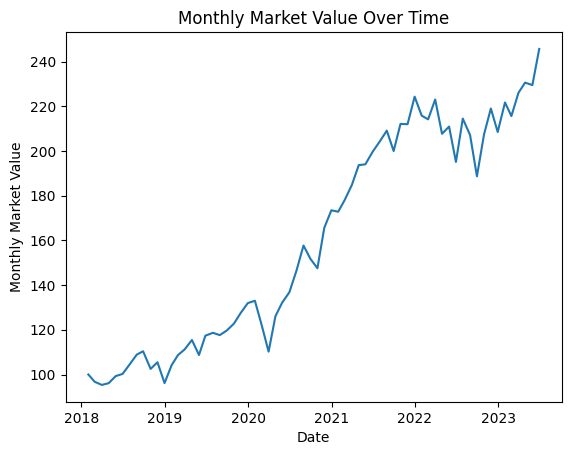

In [25]:
# Plot monthly market value
plt.plot(market_monthly_returns.index, (100 * (1 + market_monthly_returns).cumprod()).values)
plt.xlabel('Date')
plt.ylabel('Monthly Market Value')
plt.title('Monthly Market Value Over Time')
plt.show()

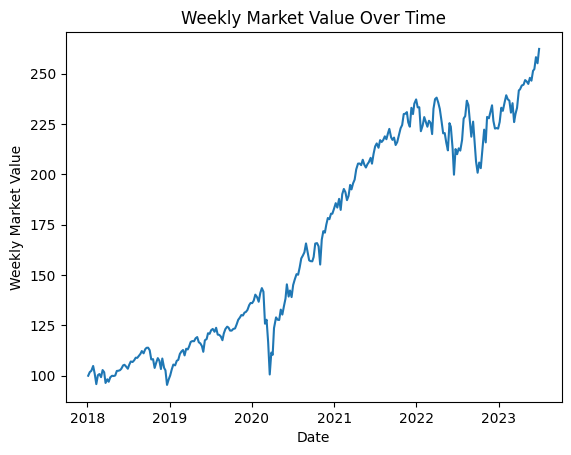

In [26]:
# Plot weekly market returns
plt.plot(market_weekly_returns.index, (100 * (1 + market_weekly_returns).cumprod()).values)
plt.xlabel('Date')
plt.ylabel('Weekly Market Value')
plt.title('Weekly Market Value Over Time')
plt.show()

### Ratio Quantile Trading Signals

In [27]:
def ratio_quantile_trading_signal(df, column: Union[str, Dict], top_quantile_threshold=0.9, bottom_quantile_threshold=0.1, direction=1):

    if type(column) == dict:
        top_quantile = df.copy()
        bottom_quantile = df.copy()

        for col, col_dir in column.items():
            top_quantile[col] = top_quantile[col] * col_dir
            bottom_quantile[col] = bottom_quantile[col] * col_dir

            top_quantile_value = top_quantile[col].quantile(top_quantile_threshold)
            top_quantile = top_quantile.loc[top_quantile[col] >= top_quantile_value]

            bottom_quantile_value = bottom_quantile[col].quantile(bottom_quantile_threshold)
            bottom_quantile = bottom_quantile.loc[bottom_quantile[col] <= bottom_quantile_value]

    elif type(column) == str:
        top_quantile_value = df[column].quantile(top_quantile_threshold)
        top_quantile = df.loc[df[column] >= top_quantile_value]

        bottom_quantile_value = df[column].quantile(bottom_quantile_threshold)
        bottom_quantile = df.loc[df[column] <= bottom_quantile_value]

    top_quantile['weights'] = top_quantile['mkt_val'] / top_quantile['mkt_val'].sum()
    top_quantile['signal'] = direction

    bottom_quantile['weights'] = bottom_quantile['mkt_val'] / bottom_quantile['mkt_val'].sum()
    bottom_quantile['signal'] = -1 * direction

    positioning = pd.concat([top_quantile[['ticker','weights','signal']], bottom_quantile[['ticker','weights','signal']]])
    positioning = pd.merge(df[['ticker','adj_close']], positioning, on='ticker', how='left').fillna(0)

    return positioning

In [28]:
def ratio_rank_quantile_trading_signal(df, column: Union[str, Dict], top_quantile_threshold=0.9, bottom_quantile_threshold=0.1, direction=1):

    if type(column) == dict:
        top_quantile = df.copy()
        bottom_quantile = df.copy()

        for col, col_dir in column.items():
            top_quantile[col] = top_quantile[col] * col_dir
            bottom_quantile[col] = bottom_quantile[col] * col_dir

            top_quantile_value = top_quantile[col].quantile(top_quantile_threshold)
            top_quantile = top_quantile.loc[top_quantile[col] >= top_quantile_value]

            bottom_quantile_value = bottom_quantile[col].quantile(bottom_quantile_threshold)
            bottom_quantile = bottom_quantile.loc[bottom_quantile[col] <= bottom_quantile_value]

            # Normalized rank for the top quantile with highest value getting highest rank
            top_quantile[f'rank_{col}'] = (top_quantile[col].rank(method='average', ascending=True) - 0.5) / top_quantile[col].shape[0]

            # Normalized rank for the bottom quantile with lowest value getting highest rank
            bottom_quantile[f'rank_{col}'] = (bottom_quantile[col].rank(method='average', ascending=False) - 0.5) / bottom_quantile[col].shape[0]

        top_quantile['rank'] = top_quantile[[f'rank_{col}' for col in column.keys()]].mean(axis=1)
        bottom_quantile['rank'] = bottom_quantile[[f'rank_{col}' for col in column.keys()]].mean(axis=1)

    elif type(column) == str:
        top_quantile_value = df[column].quantile(top_quantile_threshold)
        top_quantile = df.loc[df[column] >= top_quantile_value]

        bottom_quantile_value = df[column].quantile(bottom_quantile_threshold)
        bottom_quantile = df.loc[df[column] <= bottom_quantile_value]

        # Normalized rank for the top quantile with highest value getting highest rank
        top_quantile['rank'] = (top_quantile[column].rank(method='average', ascending=True) - 0.5) / top_quantile[column].shape[0]

        # Normalized rank for the bottom quantile with lowest value getting highest rank
        bottom_quantile['rank'] = (bottom_quantile[column].rank(method='average', ascending=False) - 0.5) / bottom_quantile[column].shape[0]

    top_quantile['weights'] = (top_quantile['mkt_val'] * top_quantile['rank']) / (top_quantile['mkt_val'] * top_quantile['rank']).sum()
    top_quantile['signal'] = direction

    bottom_quantile['weights'] = (bottom_quantile['mkt_val'] * bottom_quantile['rank']) / (bottom_quantile['mkt_val'] * bottom_quantile['rank']).sum()
    bottom_quantile['signal'] = -1 * direction

    positioning = pd.concat([top_quantile[['ticker','weights','signal']], bottom_quantile[['ticker','weights','signal']]])
    positioning = pd.merge(df[['ticker','adj_close']], positioning, on='ticker', how='left').fillna(0)

    return positioning

In [29]:
def simulate_trading(df, column: Union[str, Dict], signal_func = ratio_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, top_quantile_threshold=0.9, bottom_quantile_threshold=0.1, direction=1, plot=True):

    col_map = {
        'tot_debt_tot_equity': 'Debt to Equity',
        'tot_debt_tot_equity_pct_change': 'Debt to Equity Pct Change',
        'ret_invst': 'Return on Investment',
        'ret_invst_pct_change': 'Return on Investment Pct Change',
        'price_earnings': 'Price to Earnings',
        'price_earnings_pct_change': 'Price to Earnings Pct Change'
    }

    if type(column) == dict:
        col_name = '-'.join([col_map[col] for col in column.keys()])
    elif type(column) == str:
        col_name = col_map[column]

    capital = initial_capital

    if rebalance_frequency == 'M':
        period_col = 'month'
    elif rebalance_frequency == 'W':
        period_col = 'week'
    else:
        raise ValueError("rebalance_frequency must be either 'M' or 'W'")

    ### Start portfolio ###
    start_date = df['date'].min()
    df_start_date = df.loc[df_sub['date']==start_date]

    positioning = signal_func(df_start_date, 'tot_debt_tot_equity', direction=-1)
    positioning['cap'] = (positioning['signal'] * positioning['weights'] * (capital / 20))
    positioning['pos'] = positioning['cap'] / positioning['adj_close']

    short_capital = capital / 20
    last_date = start_date

    ### Period end dates ###
    period_end_dates = df.groupby(period_col)['date'].max().tolist()
    period_end_dates.sort()

    capital_over_time = []
    for period_end in period_end_dates:
        period_data = df.loc[df['date']==period_end]

        avg_rate = period_data[f'avg_{period_col}ly_rate'].iloc[0]
        short_interest = short_capital * ((period_end - last_date).days / 365) * ((avg_rate - 1) / 100)

        pnl = ((positioning['pos'].values * period_data.set_index('ticker').loc[positioning['ticker'], 'adj_close'].values) - positioning['cap'].values).sum()

        period_end_stats = [period_end, capital, short_interest, pnl]

        capital = capital + short_interest + pnl

        period_end_stats.append(capital)
        capital_over_time.append(period_end_stats)

        positioning = signal_func(period_data, column, direction=direction)
        positioning['cap'] = (positioning['signal'] * positioning['weights'] * (capital / 2))
        positioning['pos'] = positioning['cap'] / positioning['adj_close']

        short_capital = capital / 2
        last_date = period_end

    capital_over_time = pd.DataFrame(capital_over_time, columns=['date','start_capital','short_interest','pnl','end_capital'])

    if plot:
        # plot capital over time
        plt.plot(capital_over_time['date'], capital_over_time['end_capital'])
        plt.xlabel('Date')
        plt.ylabel('Capital')
        plt.title(f'{rebalance_frequency}{period_col[1:]}ly Rebalanced {col_name} Quantile Trading')
        plt.show()

    return capital_over_time

In [30]:
def compute_statistics(capital_over_time, rebalance_frequency='M', initial_capital=10_000_000.00):

    if rebalance_frequency == 'M':
        annualization_factor = 12
        market_returns = market_monthly_returns
    elif rebalance_frequency == 'W':
        annualization_factor = 52
        market_returns = market_weekly_returns
    else:
        raise ValueError("rebalance_frequency must be either 'M' or 'W'")

    # Compute Sharpe Ratio
    capital_over_time['returns'] = capital_over_time['end_capital'].pct_change().fillna(0)
    sharpe_ratio = (capital_over_time['returns'].mean() / capital_over_time['returns'].std()) * np.sqrt(annualization_factor)

    # Compute Max Drawdown
    capital_over_time['cum_return'] = (1 + capital_over_time['returns']).cumprod()
    capital_over_time['cum_max'] = capital_over_time['cum_return'].cummax()
    capital_over_time['drawdown'] = (capital_over_time['cum_return'] - capital_over_time['cum_max']) / capital_over_time['cum_max']
    max_drawdown = capital_over_time['drawdown'].min()

    # Compute Total Return and CAGR
    total_return = (capital_over_time['end_capital'].iloc[-1] / initial_capital) - 1

    num_years = (capital_over_time['date'].iloc[-1] - capital_over_time['date'].iloc[0]).days / 365.25
    cagr = (capital_over_time['end_capital'].iloc[-1] / initial_capital) ** (1 / num_years) - 1

    # Compute market beta based on returns of portfolio and market returns
    market_reg = sm.OLS(
        capital_over_time['returns'].values,
        sm.add_constant(market_returns[capital_over_time['date']].values)
    ).fit()

    market_beta = market_reg.params[1]
    market_intercept = market_reg.params[0]
    market_r2 = market_reg.rsquared

    # Compute downside beta based on returns of portfolio and market returns
    market_reg_downside = sm.OLS(
        capital_over_time.loc[capital_over_time['returns'] < 0, 'returns'].values,
        sm.add_constant(market_returns[capital_over_time.loc[capital_over_time['returns'] < 0, 'date']].values)
    ).fit()

    market_beta_downside = market_reg_downside.params[1]
    market_intercept_downside = market_reg_downside.params[0]
    market_r2_downside = market_reg_downside.rsquared

    portfolio_stats = {
        'Initial Capital': initial_capital,
        'Final Capital': capital_over_time['end_capital'].iloc[-1],
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown,
        'Total Return': total_return,
        'CAGR': cagr,
        'Market Beta': market_beta,
        'Market Intercept': market_intercept,
        'Market R-squared': market_r2,
        'Downside Beta': market_beta_downside,
        'Downside Intercept': market_intercept_downside,
        'Downside R-squared': market_r2_downside
    }

    for key, value in portfolio_stats.items():
        if isinstance(value, float):
            if 'Return' in key or 'CAGR' in key or 'Drawdown' in key:
                print(f'{key}: {value*100:.2f}%')
            else:
                print(f'{key}: {value:.4f}')
        else:
            print(f'{key}: {value}')

    return portfolio_stats

---

#### Monthly Rebalanced Debt to Equity Ratio Quantile Trading

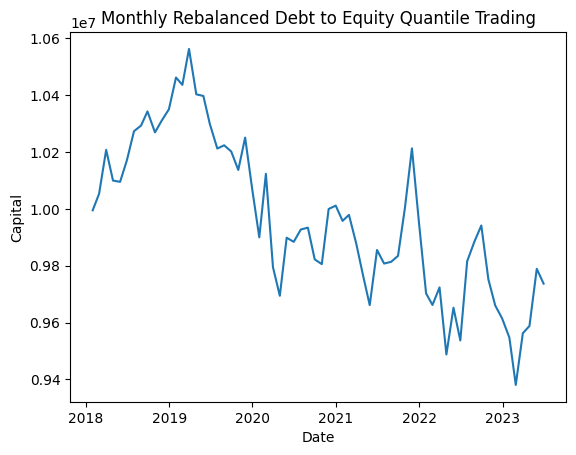

Initial Capital: 10000000.0000
Final Capital: 9736936.4872
Sharpe Ratio: -0.0818
Max Drawdown: -11.20%
Total Return: -2.63%
CAGR: -0.49%
Market Beta: 0.0440
Market Intercept: -0.0010
Market R-squared: 0.0303
Downside Beta: 0.0266
Downside Intercept: -0.0109
Downside R-squared: 0.0332


In [31]:
# Simulate Monthly Rebalanced Debt to Equity Ratio Quantile Trading
capital_over_time_de_ratio_monthly = simulate_trading(df_sub, 'tot_debt_tot_equity', signal_func=ratio_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_de_ratio_monthly = compute_statistics(capital_over_time_de_ratio_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Debt to Equity Ratio Quantile Trading With Rank based Weights

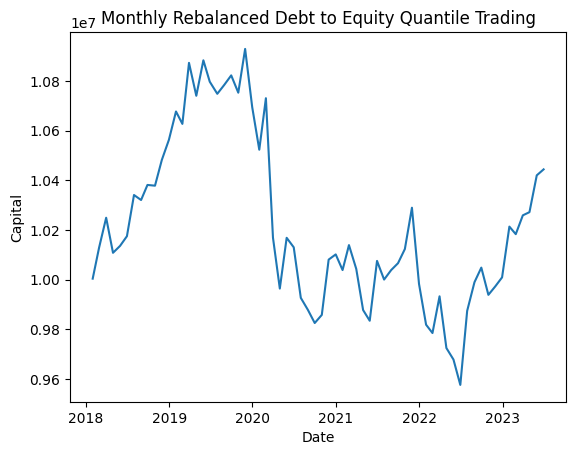

Initial Capital: 10000000.0000
Final Capital: 10444546.2076
Sharpe Ratio: 0.1817
Max Drawdown: -12.39%
Total Return: 4.45%
CAGR: 0.81%
Market Beta: 0.0307
Market Intercept: 0.0003
Market R-squared: 0.0123
Downside Beta: 0.0270
Downside Intercept: -0.0122
Downside R-squared: 0.0195


In [32]:
# Simulate Monthly Rebalanced Debt to Equity Ratio Quantile Trading
capital_over_time_de_ratio_monthly = simulate_trading(df_sub, 'tot_debt_tot_equity', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_de_ratio_monthly = compute_statistics(capital_over_time_de_ratio_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Debt to Equity Ratio Pct Change Quantile Trading

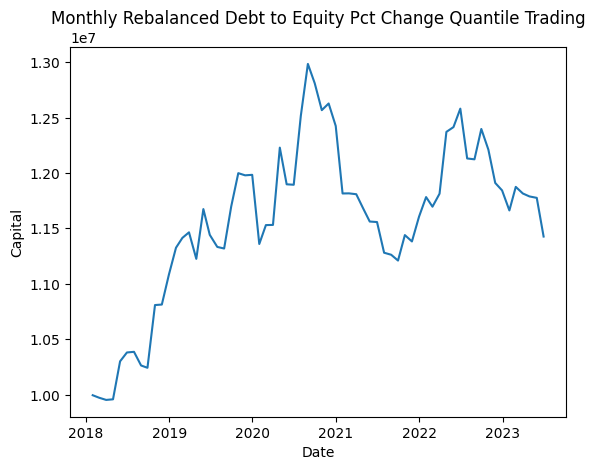

Initial Capital: 10000000.0000
Final Capital: 11427195.0741
Sharpe Ratio: 0.3509
Max Drawdown: -13.67%
Total Return: 14.27%
CAGR: 2.50%
Market Beta: -0.0590
Market Intercept: 0.0032
Market R-squared: 0.0187
Downside Beta: -0.1045
Downside Intercept: -0.0107
Downside R-squared: 0.0915


In [33]:
# Simulate Monthly Rebalanced Debt to Equity Ratio Change Quantile Trading
capital_over_time_de_ratio_pct_change_monthly = simulate_trading(df_sub, 'tot_debt_tot_equity_pct_change', signal_func=ratio_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_de_ratio_pct_change_monthly = compute_statistics(capital_over_time_de_ratio_pct_change_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Debt to Equity Ratio Pct Change Quantile Trading With Rank based Weights

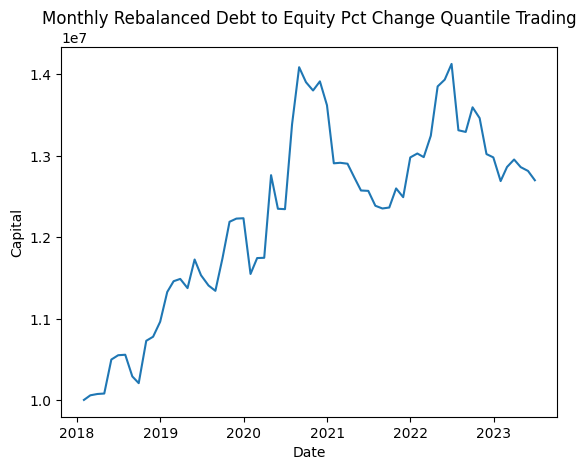

Initial Capital: 10000000.0000
Final Capital: 12699481.2503
Sharpe Ratio: 0.5156
Max Drawdown: -12.31%
Total Return: 26.99%
CAGR: 4.52%
Market Beta: -0.0061
Market Intercept: 0.0041
Market R-squared: 0.0001
Downside Beta: -0.1311
Downside Intercept: -0.0122
Downside R-squared: 0.0968


In [34]:
# Simulate Monthly Rebalanced Debt to Equity Ratio Change Quantile Trading
capital_over_time_de_ratio_pct_change_monthly = simulate_trading(df_sub, 'tot_debt_tot_equity_pct_change', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_de_ratio_pct_change_monthly = compute_statistics(capital_over_time_de_ratio_pct_change_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

### Observations:
- Debt to Equity (DE) trading based on market cap weighted quantile strategy yields negative returns.
- DE trading shows a positive return when rank based weights are used.
- Percentage change in DE trading yields a higher positive returns as compared to absolute DE values.
- Rank based weighting in the percentage change strategy further enhances returns.
- Rank based weighting provides more volatility, magnifying both gains (total returns) and losses (max drawdowns).
- Market beta is small but positive for all strategies, indicating a correlation with market movements.
- Downside beta (absolute) is higher than overall market beta for pct change trading suggesting greater sensitivity during market downturns.
- Downside beta is negative for pct change trading indicating an inverse relationship during market downturns.

#### Weekly Rebalanced Debt to Equity Ratio Quantile Trading

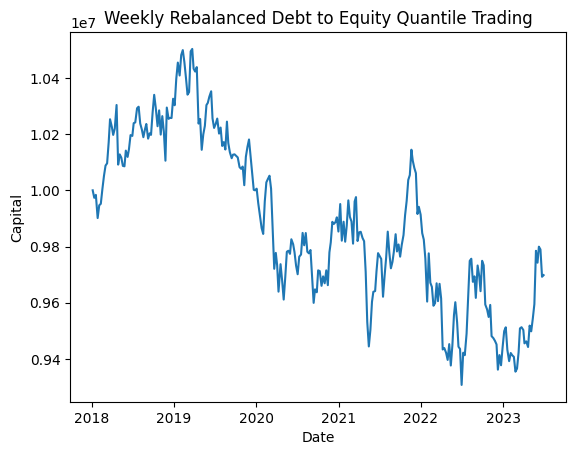

Initial Capital: 10000000.0000
Final Capital: 9698463.9534
Sharpe Ratio: -0.0887
Max Drawdown: -11.39%
Total Return: -3.02%
CAGR: -0.56%
Market Beta: 0.0576
Market Intercept: -0.0003
Market R-squared: 0.0531
Downside Beta: 0.0296
Downside Intercept: -0.0054
Downside R-squared: 0.0371


In [226]:
# Simulate Weekly Rebalanced Debt to Equity Ratio Quantile Trading
capital_over_time_de_ratio_weekly = simulate_trading(df_sub, 'tot_debt_tot_equity', signal_func=ratio_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_de_ratio_weekly = compute_statistics(capital_over_time_de_ratio_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Debt to Equity Ratio Quantile Trading With Rank based Weights

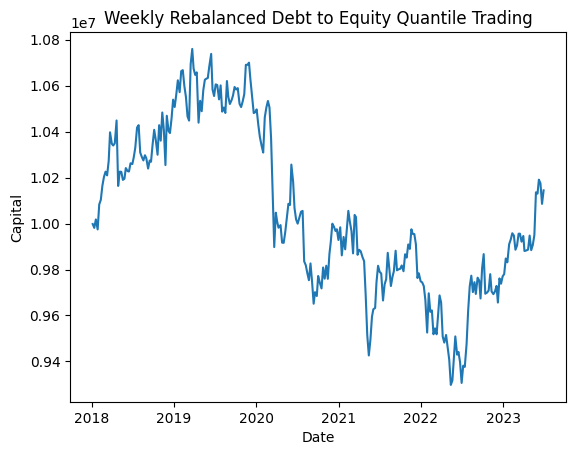

Initial Capital: 10000000.0000
Final Capital: 10144179.0118
Sharpe Ratio: 0.0752
Max Drawdown: -13.58%
Total Return: 1.44%
CAGR: 0.26%
Market Beta: 0.0786
Market Intercept: -0.0002
Market R-squared: 0.0778
Downside Beta: 0.0457
Downside Intercept: -0.0057
Downside R-squared: 0.0607


In [227]:
# Simulate Weekly Rebalanced Debt to Equity Ratio Quantile Trading
capital_over_time_de_ratio_weekly = simulate_trading(df_sub, 'tot_debt_tot_equity', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_de_ratio_weekly = compute_statistics(capital_over_time_de_ratio_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Debt to Equity Ratio Pct Change Quantile Trading

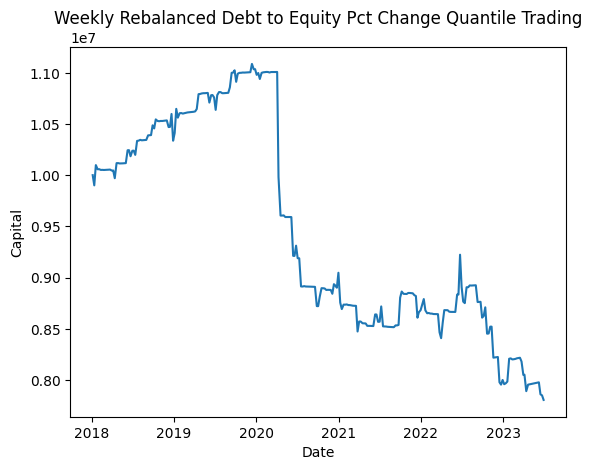

Initial Capital: 10000000.0000
Final Capital: 7803799.4533
Sharpe Ratio: -0.5353
Max Drawdown: -29.62%
Total Return: -21.96%
CAGR: -4.42%
Market Beta: -0.0624
Market Intercept: -0.0006
Market R-squared: 0.0246
Downside Beta: -0.1193
Downside Intercept: -0.0055
Downside R-squared: 0.0809


In [228]:
# Simulate Weekly Rebalanced Debt to Equity Ratio Change Quantile Trading
capital_over_time_de_ratio_pct_change_weekly = simulate_trading(df_sub, 'tot_debt_tot_equity_pct_change', signal_func=ratio_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_de_ratio_pct_change_weekly = compute_statistics(capital_over_time_de_ratio_pct_change_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Debt to Equity Ratio Pct Change Quantile Trading With Rank based Weights

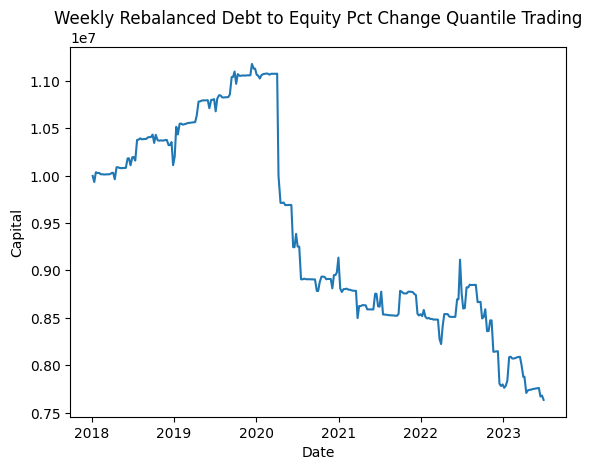

Initial Capital: 10000000.0000
Final Capital: 7634361.1285
Sharpe Ratio: -0.5350
Max Drawdown: -31.71%
Total Return: -23.66%
CAGR: -4.81%
Market Beta: -0.0574
Market Intercept: -0.0007
Market R-squared: 0.0178
Downside Beta: -0.1176
Downside Intercept: -0.0060
Downside R-squared: 0.0677


In [229]:
# Simulate Weekly Rebalanced Debt to Equity Ratio Change Quantile Trading
capital_over_time_de_ratio_pct_change_weekly = simulate_trading(df_sub, 'tot_debt_tot_equity_pct_change', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_de_ratio_pct_change_weekly = compute_statistics(capital_over_time_de_ratio_pct_change_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

---

#### Monthly Rebalanced Return on Investment Quantile Trading

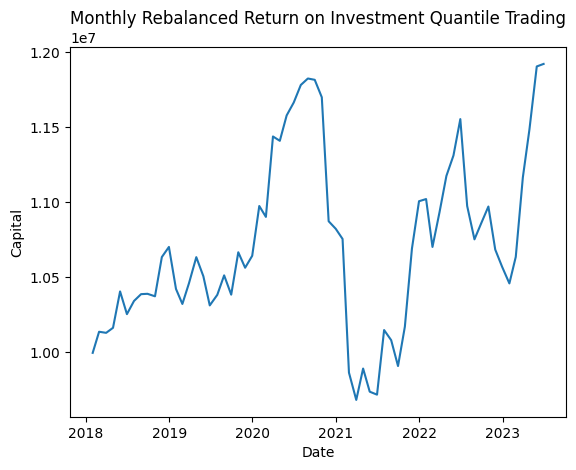

Initial Capital: 10000000.0000
Final Capital: 11918623.4145
Sharpe Ratio: 0.4208
Max Drawdown: -18.10%
Total Return: 19.19%
CAGR: 3.30%
Market Beta: -0.0996
Market Intercept: 0.0045
Market R-squared: 0.0451
Downside Beta: -0.1319
Downside Intercept: -0.0153
Downside R-squared: 0.1476


In [35]:
# Simulate Monthly Rebalanced Return on Investment Quantile Trading
capital_over_time_ret_invst_monthly = simulate_trading(df_sub, 'ret_invst', signal_func=ratio_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=1)

portfolio_stats_ret_invst_monthly = compute_statistics(capital_over_time_ret_invst_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Return on Investment Quantile Trading With Rank based Weights

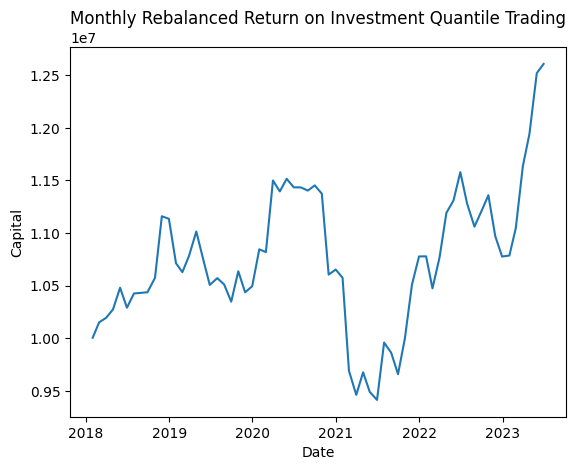

Initial Capital: 10000000.0000
Final Capital: 12607039.2978
Sharpe Ratio: 0.4926
Max Drawdown: -18.25%
Total Return: 26.07%
CAGR: 4.38%
Market Beta: -0.1136
Market Intercept: 0.0056
Market R-squared: 0.0472
Downside Beta: -0.0913
Downside Intercept: -0.0176
Downside R-squared: 0.0811


In [36]:
# Simulate Monthly Rebalanced Return on Investment Quantile Trading
capital_over_time_ret_invst_monthly = simulate_trading(df_sub, 'ret_invst', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=1)

portfolio_stats_ret_invst_monthly = compute_statistics(capital_over_time_ret_invst_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Return on Investment Pct Change Quantile Trading

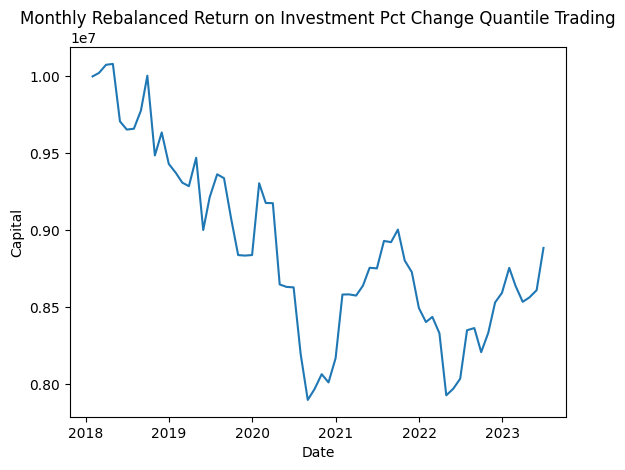

Initial Capital: 10000000.0000
Final Capital: 8881618.4172
Sharpe Ratio: -0.2354
Max Drawdown: -21.65%
Total Return: -11.18%
CAGR: -2.17%
Market Beta: 0.0461
Market Intercept: -0.0022
Market R-squared: 0.0113
Downside Beta: 0.0039
Downside Intercept: -0.0182
Downside R-squared: 0.0002


In [37]:
# Simulate Monthly Rebalanced Return on Investment Quantile Trading
capital_over_time_ret_invst_pct_change_monthly = simulate_trading(df_sub, 'ret_invst_pct_change', signal_func=ratio_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=1)

portfolio_stats_ret_invst_pct_change_monthly = compute_statistics(capital_over_time_ret_invst_pct_change_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Return on Investment Pct Change Quantile Trading With Rank based Weights

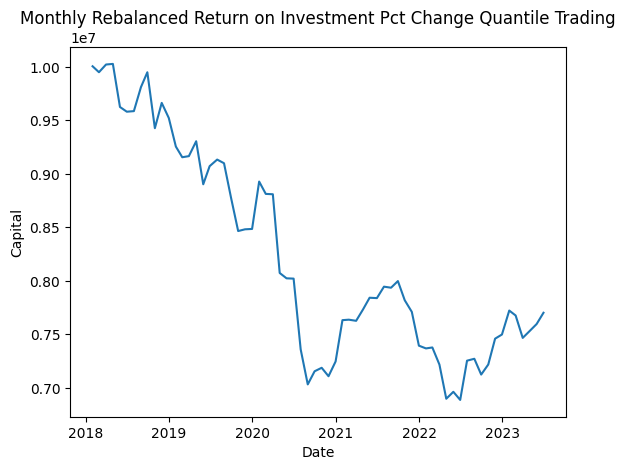

Initial Capital: 10000000.0000
Final Capital: 7701357.3970
Sharpe Ratio: -0.4707
Max Drawdown: -31.31%
Total Return: -22.99%
CAGR: -4.71%
Market Beta: 0.0006
Market Intercept: -0.0036
Market R-squared: 0.0000
Downside Beta: -0.1075
Downside Intercept: -0.0219
Downside R-squared: 0.0947


In [38]:
# Simulate Monthly Rebalanced Return on Investment Quantile Trading
capital_over_time_ret_invst_pct_change_monthly = simulate_trading(df_sub, 'ret_invst_pct_change', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=1)

portfolio_stats_ret_invst_pct_change_monthly = compute_statistics(capital_over_time_ret_invst_pct_change_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

### Observations:
- Return on Investment (ROI) trading based on absolute value quantile strategy yields positive returns.
- ROI trading shows a negative return when pct change in ROI is used.
- Rank based weighting provides more volatility, magnifying both gains (total returns) and losses (max drawdowns).
- Market beta is small but positive for pct change strategies, and negative for absolute value strategies, indicating differing correlations with market movements.
- Downside beta is generally negative for both strategies, indicating an inverse relationship during market downturns.

#### Weekly Rebalanced Return on Investment Quantile Trading

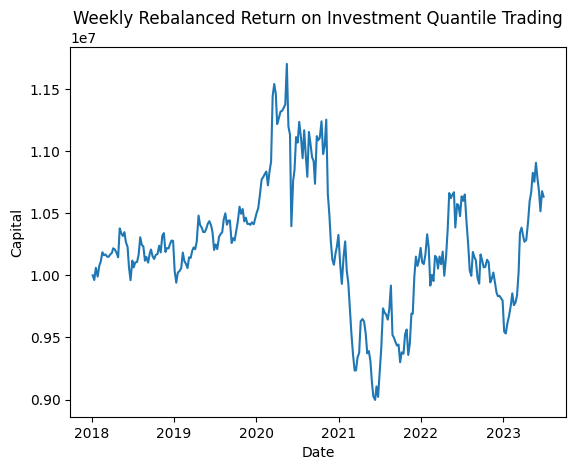

Initial Capital: 10000000.0000
Final Capital: 10633617.5624
Sharpe Ratio: 0.1624
Max Drawdown: -23.12%
Total Return: 6.34%
CAGR: 1.13%
Market Beta: -0.1035
Market Intercept: 0.0007
Market R-squared: 0.0428
Downside Beta: -0.0771
Downside Intercept: -0.0092
Downside R-squared: 0.0308


In [236]:
# Simulate Weekly Rebalanced Return on Investment Quantile Trading
capital_over_time_ret_invst_weekly = simulate_trading(df_sub, 'ret_invst', signal_func=ratio_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=1)

portfolio_stats_ret_invst_weekly = compute_statistics(capital_over_time_ret_invst_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Return on Investment Quantile Trading With Rank based Weights

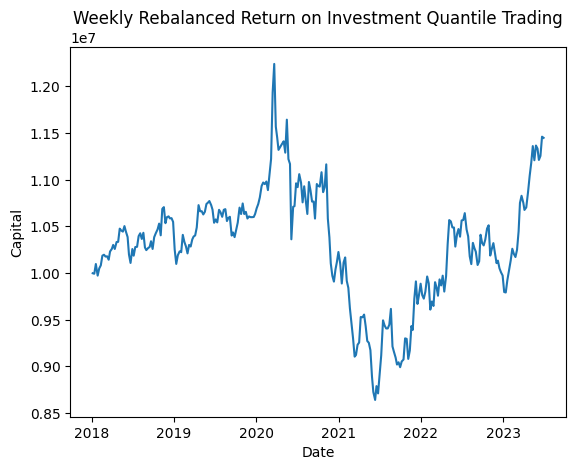

Initial Capital: 10000000.0000
Final Capital: 11448765.3658
Sharpe Ratio: 0.2793
Max Drawdown: -29.42%
Total Return: 14.49%
CAGR: 2.50%
Market Beta: -0.1515
Market Intercept: 0.0012
Market R-squared: 0.0739
Downside Beta: -0.0900
Downside Intercept: -0.0101
Downside R-squared: 0.0398


In [237]:
# Simulate Weekly Rebalanced Return on Investment Quantile Trading
capital_over_time_ret_invst_weekly = simulate_trading(df_sub, 'ret_invst', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=1)

portfolio_stats_ret_invst_weekly = compute_statistics(capital_over_time_ret_invst_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Return on Investment Pct Change Quantile Trading

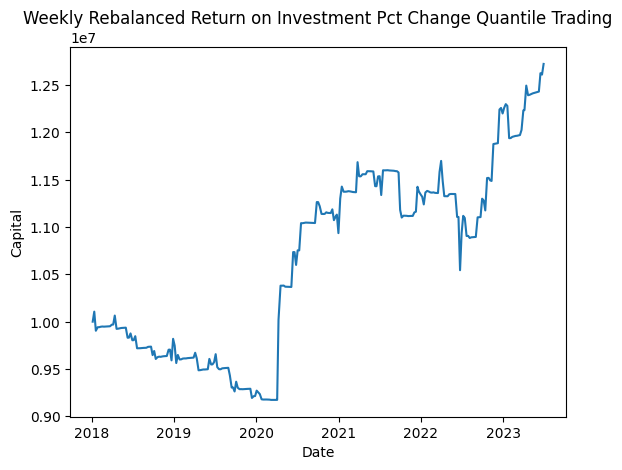

Initial Capital: 10000000.0000
Final Capital: 12722500.6989
Sharpe Ratio: 0.5949
Max Drawdown: -9.86%
Total Return: 27.23%
CAGR: 4.49%
Market Beta: 0.0631
Market Intercept: 0.0007
Market R-squared: 0.0249
Downside Beta: -0.0231
Downside Intercept: -0.0046
Downside R-squared: 0.0055


In [238]:
# Simulate Weekly Rebalanced Return on Investment Quantile Trading
capital_over_time_ret_invst_pct_change_weekly = simulate_trading(df_sub, 'ret_invst_pct_change', signal_func=ratio_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=1)

portfolio_stats_ret_invst_pct_change_weekly = compute_statistics(capital_over_time_ret_invst_pct_change_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Return on Investment Pct Change Quantile Trading With Rank based Weights

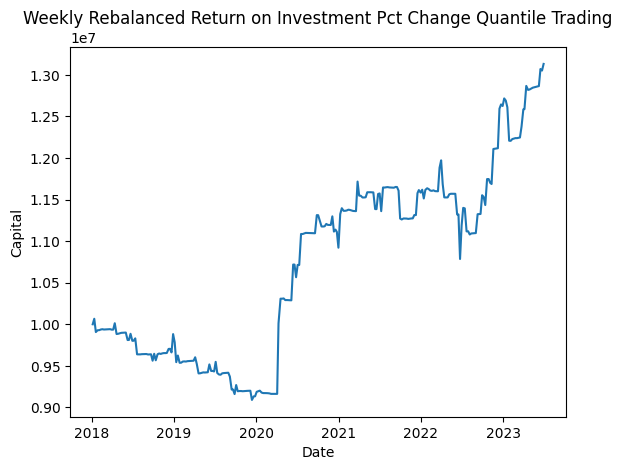

Initial Capital: 10000000.0000
Final Capital: 13133047.2889
Sharpe Ratio: 0.6421
Max Drawdown: -9.92%
Total Return: 31.33%
CAGR: 5.10%
Market Beta: 0.0577
Market Intercept: 0.0008
Market R-squared: 0.0190
Downside Beta: -0.0247
Downside Intercept: -0.0047
Downside R-squared: 0.0056


In [239]:
# Simulate Weekly Rebalanced Return on Investment Quantile Trading
capital_over_time_ret_invst_pct_change_weekly = simulate_trading(df_sub, 'ret_invst_pct_change', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=1)

portfolio_stats_ret_invst_pct_change_weekly = compute_statistics(capital_over_time_ret_invst_pct_change_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

---

#### Monthly Rebalanced Price to Earnings Quantile Trading

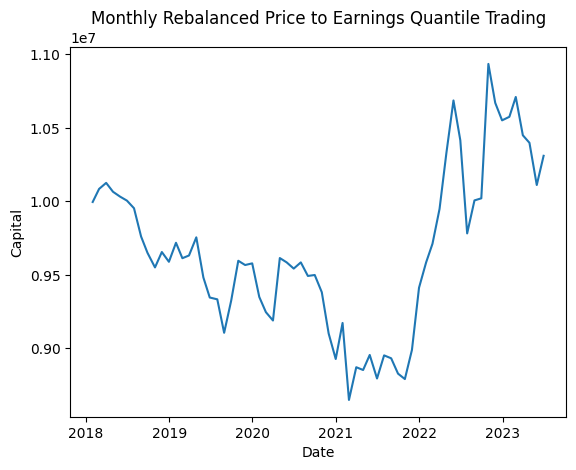

Initial Capital: 10000000.0000
Final Capital: 10309300.6158
Sharpe Ratio: 0.1085
Max Drawdown: -14.58%
Total Return: 3.09%
CAGR: 0.56%
Market Beta: 0.0476
Market Intercept: 0.0000
Market R-squared: 0.0109
Downside Beta: -0.0492
Downside Intercept: -0.0144
Downside R-squared: 0.0368


In [39]:
# Simulate Monthly Rebalanced Price to Earnings Quantile Trading
capital_over_time_pe_ratio_monthly = simulate_trading(df_sub, 'price_earnings', signal_func=ratio_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_pe_ratio_monthly = compute_statistics(capital_over_time_pe_ratio_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Price to Earnings Quantile Trading With Rank based Weights

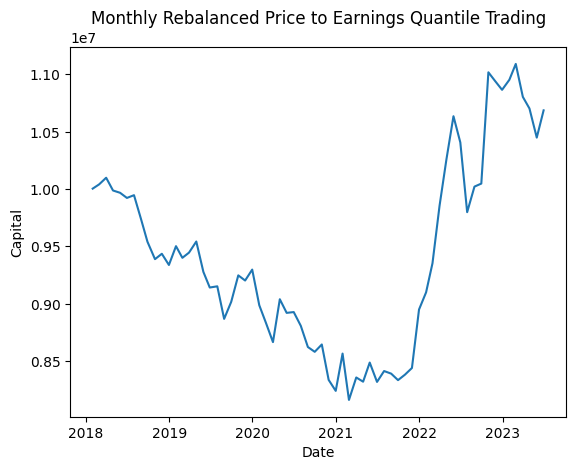

Initial Capital: 10000000.0000
Final Capital: 10686723.4699
Sharpe Ratio: 0.1783
Max Drawdown: -19.19%
Total Return: 6.87%
CAGR: 1.24%
Market Beta: 0.0605
Market Intercept: 0.0004
Market R-squared: 0.0151
Downside Beta: -0.0491
Downside Intercept: -0.0169
Downside R-squared: 0.0466


In [40]:
# Simulate Monthly Rebalanced Price to Earnings Quantile Trading
capital_over_time_pe_ratio_monthly = simulate_trading(df_sub, 'price_earnings', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_pe_ratio_monthly = compute_statistics(capital_over_time_pe_ratio_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Price to Earnings Pct Change Quantile Trading

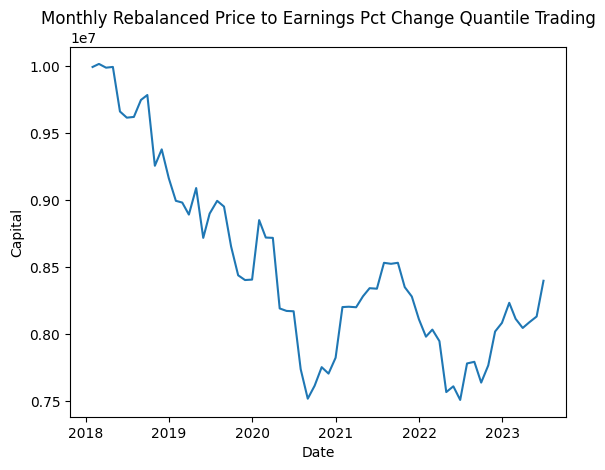

Initial Capital: 10000000.0000
Final Capital: 8399680.9643
Sharpe Ratio: -0.3708
Max Drawdown: -25.03%
Total Return: -16.00%
CAGR: -3.17%
Market Beta: 0.0597
Market Intercept: -0.0033
Market R-squared: 0.0195
Downside Beta: -0.0028
Downside Intercept: -0.0177
Downside R-squared: 0.0001


In [41]:
# Simulate Monthly Rebalanced Price to Earnings Quantile Trading
capital_over_time_pe_ratio_pct_change_monthly = simulate_trading(df_sub, 'price_earnings_pct_change', signal_func=ratio_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_pe_ratio_pct_change_monthly = compute_statistics(capital_over_time_pe_ratio_pct_change_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Price to Earnings Pct Change Quantile Trading With Rank based Weights

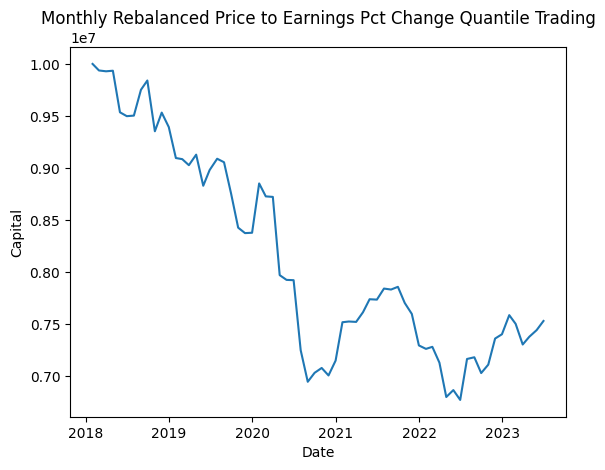

Initial Capital: 10000000.0000
Final Capital: 7532608.4501
Sharpe Ratio: -0.5152
Max Drawdown: -32.29%
Total Return: -24.67%
CAGR: -5.10%
Market Beta: 0.0008
Market Intercept: -0.0040
Market R-squared: 0.0000
Downside Beta: -0.1044
Downside Intercept: -0.0199
Downside R-squared: 0.0840


In [42]:
# Simulate Monthly Rebalanced Price to Earnings Quantile Trading
capital_over_time_pe_ratio_pct_change_monthly = simulate_trading(df_sub, 'price_earnings_pct_change', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_pe_ratio_pct_change_monthly = compute_statistics(capital_over_time_pe_ratio_pct_change_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

### Observations:
- Price to Earnings (PE) trading based on absolute value quantile strategy yields positive returns.
- PE trading shows a negative return when pct change in PE is used.
- Rank based weighting provides more volatility, magnifying both gains (total returns) and losses (max drawdowns).
- Market beta is small but positive for all strategies, indicating slight correlations with market movements.
- Downside beta is generally negative for both strategies, indicating an inverse relationship during market downturns.

#### Weekly Rebalanced Price to Earnings Quantile Trading

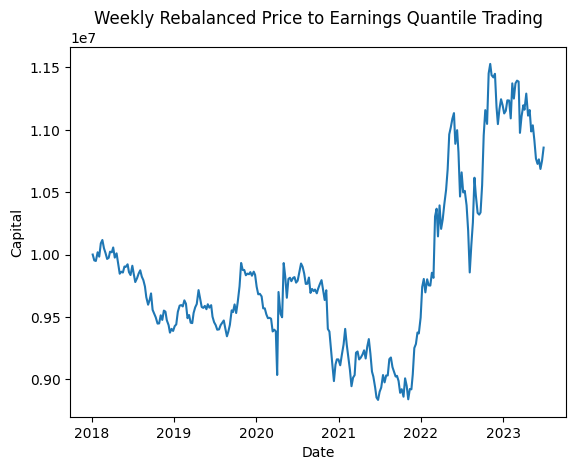

Initial Capital: 10000000.0000
Final Capital: 10857260.8870
Sharpe Ratio: 0.2131
Max Drawdown: -12.67%
Total Return: 8.57%
CAGR: 1.51%
Market Beta: 0.0019
Market Intercept: 0.0004
Market R-squared: 0.0000
Downside Beta: -0.0324
Downside Intercept: -0.0077
Downside R-squared: 0.0129


In [244]:
# Simulate Weekly Rebalanced Price to Earnings Quantile Trading
capital_over_time_pe_ratio_weekly = simulate_trading(df_sub, 'price_earnings', signal_func=ratio_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_pe_ratio_weekly = compute_statistics(capital_over_time_pe_ratio_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Price to Earnings Quantile Trading With Rank based Weights

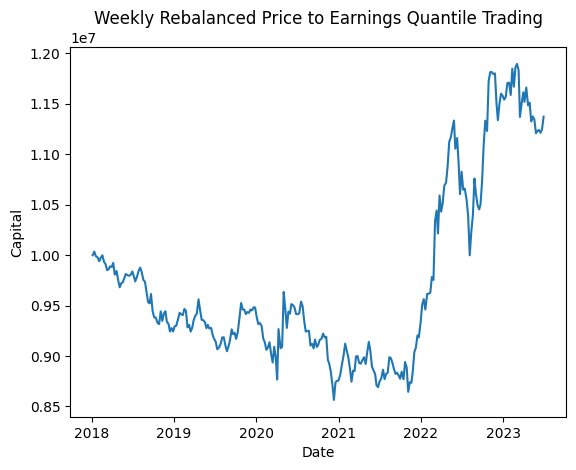

Initial Capital: 10000000.0000
Final Capital: 11370067.2937
Sharpe Ratio: 0.2980
Max Drawdown: -14.64%
Total Return: 13.70%
CAGR: 2.37%
Market Beta: -0.0214
Market Intercept: 0.0006
Market R-squared: 0.0021
Downside Beta: -0.0355
Downside Intercept: -0.0084
Downside R-squared: 0.0152


In [245]:
# Simulate Weekly Rebalanced Price to Earnings Quantile Trading
capital_over_time_pe_ratio_weekly = simulate_trading(df_sub, 'price_earnings', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_pe_ratio_weekly = compute_statistics(capital_over_time_pe_ratio_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Price to Earnings Pct Change Quantile Trading

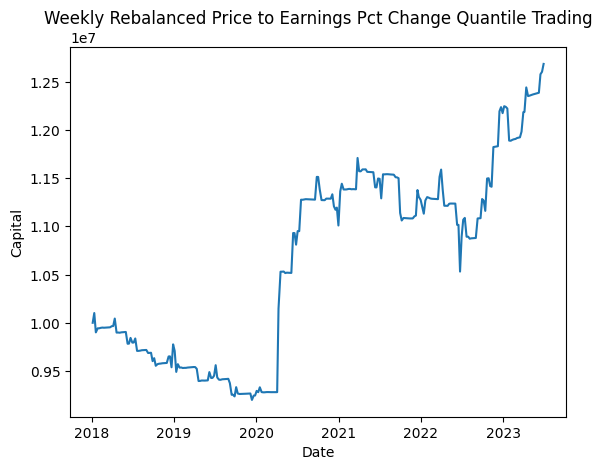

Initial Capital: 10000000.0000
Final Capital: 12686228.1103
Sharpe Ratio: 0.5897
Max Drawdown: -10.06%
Total Return: 26.86%
CAGR: 4.44%
Market Beta: 0.0621
Market Intercept: 0.0007
Market R-squared: 0.0243
Downside Beta: -0.0228
Downside Intercept: -0.0046
Downside R-squared: 0.0062


In [246]:
# Simulate Weekly Rebalanced Price to Earnings Quantile Trading
capital_over_time_pe_ratio_pct_change_weekly = simulate_trading(df_sub, 'price_earnings_pct_change', signal_func=ratio_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_pe_ratio_pct_change_weekly = compute_statistics(capital_over_time_pe_ratio_pct_change_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Price to Earnings Pct Change Quantile Trading With Rank based Weights

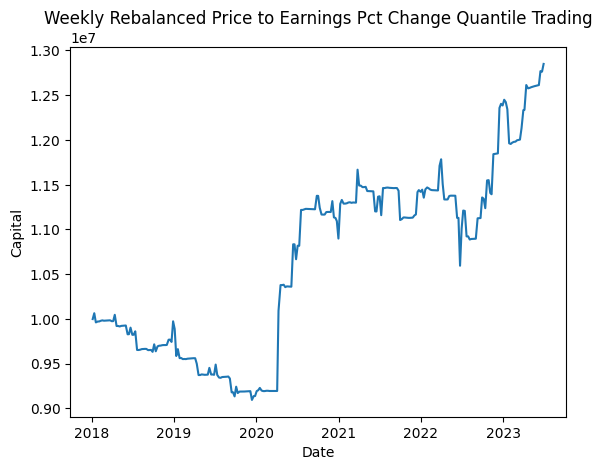

Initial Capital: 10000000.0000
Final Capital: 12849408.9253
Sharpe Ratio: 0.5796
Max Drawdown: -10.09%
Total Return: 28.49%
CAGR: 4.68%
Market Beta: 0.0575
Market Intercept: 0.0007
Market R-squared: 0.0179
Downside Beta: -0.0278
Downside Intercept: -0.0048
Downside R-squared: 0.0070


In [247]:
# Simulate Weekly Rebalanced Price to Earnings Pct Change Quantile Trading with Rank based Weights
capital_over_time_pe_ratio_pct_change_weekly = simulate_trading(df_sub, 'price_earnings_pct_change', signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00, direction=-1)

portfolio_stats_pe_ratio_pct_change_weekly = compute_statistics(capital_over_time_pe_ratio_pct_change_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

---

#### Monthly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratios

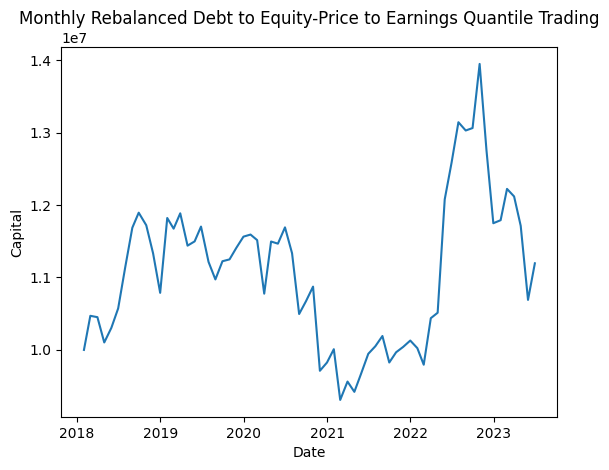

Initial Capital: 10000000.0000
Final Capital: 11192620.8879
Sharpe Ratio: 0.2098
Max Drawdown: -23.39%
Total Return: 11.93%
CAGR: 2.10%
Market Beta: 0.1493
Market Intercept: 0.0004
Market R-squared: 0.0310
Downside Beta: -0.1308
Downside Intercept: -0.0374
Downside R-squared: 0.0585


In [43]:
# Simulate Monthly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratios
capital_over_time_multi_factor_monthly = simulate_trading(df_sub, {'tot_debt_tot_equity': -1, 'price_earnings': -1}, signal_func=ratio_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00)

portfolio_stats_multi_factor_monthly = compute_statistics(capital_over_time_multi_factor_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratios With Rank based Weights

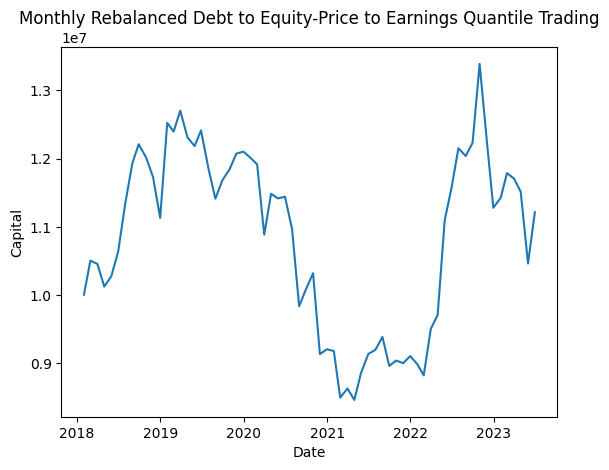

Initial Capital: 10000000.0000
Final Capital: 11213863.6214
Sharpe Ratio: 0.2058
Max Drawdown: -33.38%
Total Return: 12.14%
CAGR: 2.14%
Market Beta: 0.1768
Market Intercept: 0.0003
Market R-squared: 0.0352
Downside Beta: -0.1392
Downside Intercept: -0.0362
Downside R-squared: 0.0477


In [44]:
# Simulate Monthly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratios
capital_over_time_multi_factor_monthly = simulate_trading(df_sub, {'tot_debt_tot_equity': -1, 'price_earnings': -1}, signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00)

portfolio_stats_multi_factor_monthly = compute_statistics(capital_over_time_multi_factor_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity Ratio Pct Change and Price to Earnings Ratio Pct Change

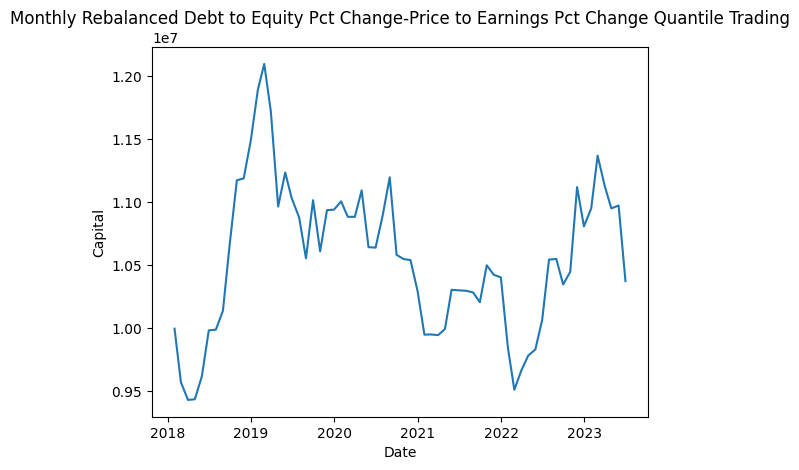

Initial Capital: 10000000.0000
Final Capital: 10373792.6405
Sharpe Ratio: 0.1176
Max Drawdown: -21.40%
Total Return: 3.74%
CAGR: 0.68%
Market Beta: 0.0686
Market Intercept: -0.0001
Market R-squared: 0.0163
Downside Beta: 0.0128
Downside Intercept: -0.0216
Downside R-squared: 0.0011


In [45]:
# Simulate Monthly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratio Pct Changes
capital_over_time_multi_factor_pct_change_monthly = simulate_trading(df_sub, {'tot_debt_tot_equity_pct_change': -1, 'price_earnings_pct_change': -1}, signal_func=ratio_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00)

portfolio_stats_multi_factor_pct_change_monthly = compute_statistics(capital_over_time_multi_factor_pct_change_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

#### Monthly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity Ratio Pct Change and Price to Earnings Ratio Pct Change With Rank based Weights

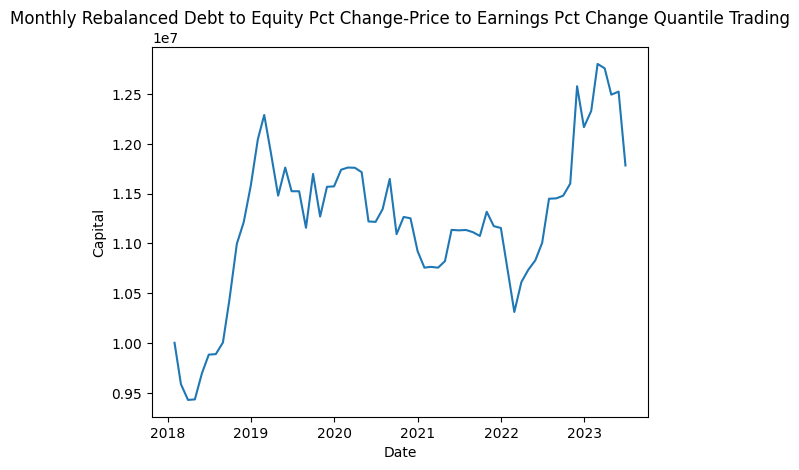

Initial Capital: 10000000.0000
Final Capital: 11781819.0871
Sharpe Ratio: 0.3645
Max Drawdown: -16.07%
Total Return: 17.82%
CAGR: 3.08%
Market Beta: 0.0238
Market Intercept: 0.0025
Market R-squared: 0.0021
Downside Beta: 0.0579
Downside Intercept: -0.0213
Downside R-squared: 0.0277


In [46]:
# Simulate Monthly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratio Pct Changes
capital_over_time_multi_factor_pct_change_monthly = simulate_trading(df_sub, {'tot_debt_tot_equity_pct_change': -1, 'price_earnings_pct_change': -1}, signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='M', initial_capital=10_000_000.00)

portfolio_stats_multi_factor_pct_change_monthly = compute_statistics(capital_over_time_multi_factor_pct_change_monthly, rebalance_frequency='M', initial_capital=10_000_000.00)

### Observations:
- DE and PE combination trading based on both - absolute value and pct change quantile strategy yields positive returns.
- Rank based weighting provides more volatility, magnifying both gains (total returns) and losses (max drawdowns).
- Rank based weighting in the pct change strategy reduces returns.
- Market beta is positive for both strategies, indicating slight correlations with market movements.
- Market beta is higher for absolute value strategy compared to pct change strategy.
- Downside beta is positive for pct change strategy and positive for absolute value strategy, indicating an inverse relationship during market downturns.

#### Weekly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratios

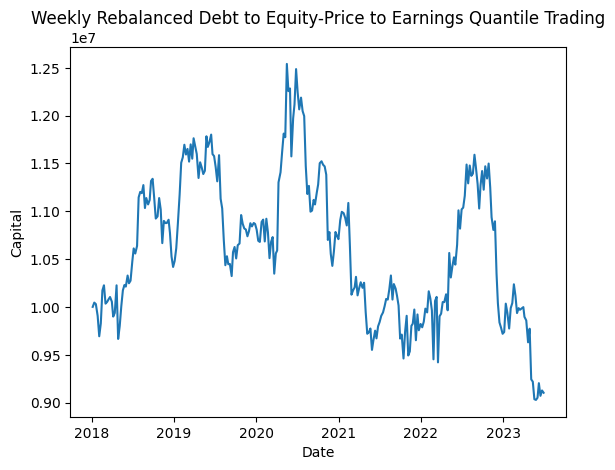

Initial Capital: 10000000.0000
Final Capital: 9103112.8276
Sharpe Ratio: -0.0469
Max Drawdown: -28.00%
Total Return: -8.97%
CAGR: -1.70%
Market Beta: 0.0085
Market Intercept: -0.0002
Market R-squared: 0.0001
Downside Beta: -0.0242
Downside Intercept: -0.0158
Downside R-squared: 0.0025


In [180]:
# Simulate Weekly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratios
capital_over_time_multi_factor_weekly = simulate_trading(df_sub, {'tot_debt_tot_equity': -1, 'price_earnings': -1}, signal_func=ratio_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00)

portfolio_stats_multi_factor_weekly = compute_statistics(capital_over_time_multi_factor_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratios With Rank based Weights

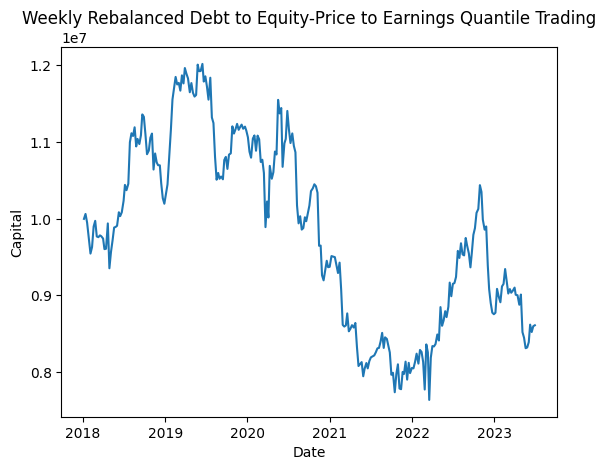

Initial Capital: 10000000.0000
Final Capital: 8609847.7393
Sharpe Ratio: -0.0931
Max Drawdown: -36.47%
Total Return: -13.90%
CAGR: -2.69%
Market Beta: 0.0492
Market Intercept: -0.0005
Market R-squared: 0.0038
Downside Beta: -0.0202
Downside Intercept: -0.0170
Downside R-squared: 0.0015


In [190]:
# Simulate Weekly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratios
capital_over_time_multi_factor_weekly = simulate_trading(df_sub, {'tot_debt_tot_equity': -1, 'price_earnings': -1}, signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00)

portfolio_stats_multi_factor_weekly = compute_statistics(capital_over_time_multi_factor_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

for key, value in portfolio_stats_multi_factor_weekly.items():
    if isinstance(value, float):
        if 'Return' in key or 'CAGR' in key or 'Drawdown' in key:
            print(f'{key}: {value*100:.2f}%')
        else:
            print(f'{key}: {value:.4f}')
    else:
        print(f'{key}: {value}')

#### Weekly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity Ratio Pct Change and Price to Earnings Ratio Pct Change

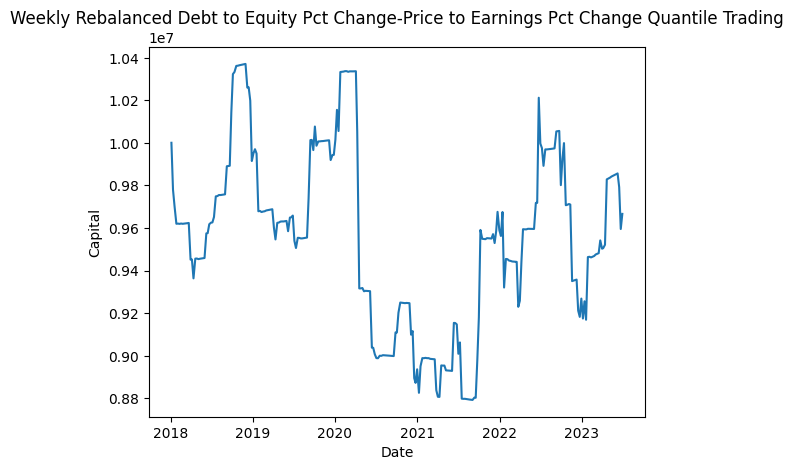

Initial Capital: 10000000.0000
Final Capital: 9666290.5864
Sharpe Ratio: -0.0391
Max Drawdown: -15.23%
Total Return: -3.34%
CAGR: -0.62%
Market Beta: -0.0072
Market Intercept: -0.0000
Market R-squared: 0.0003
Downside Beta: -0.0372
Downside Intercept: -0.0059
Downside R-squared: 0.0105


In [255]:
# Simulate Weekly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratio Pct Changes
capital_over_time_multi_factor_pct_change_weekly = simulate_trading(df_sub, {'tot_debt_tot_equity_pct_change': -1, 'price_earnings_pct_change': -1}, signal_func=ratio_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00)

portfolio_stats_multi_factor_pct_change_weekly = compute_statistics(capital_over_time_multi_factor_pct_change_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

#### Weekly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity Ratio Pct Change and Price to Earnings Ratio Pct Change With Rank based Weights

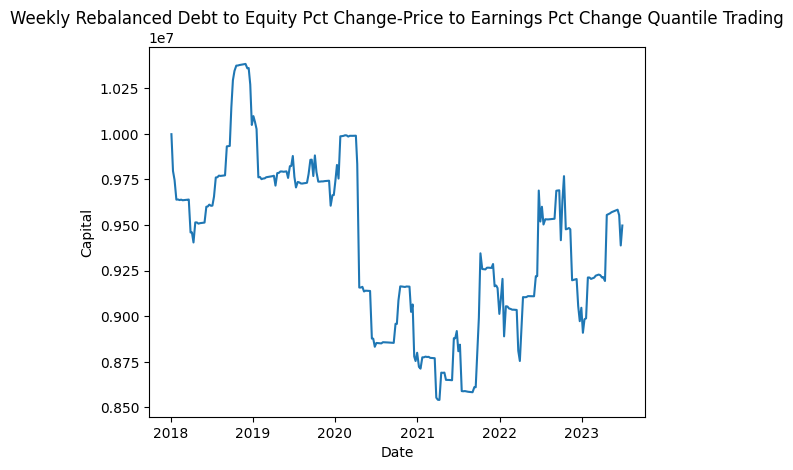

Initial Capital: 10000000.0000
Final Capital: 9497168.1898
Sharpe Ratio: -0.0839
Max Drawdown: -17.74%
Total Return: -5.03%
CAGR: -0.94%
Market Beta: -0.0014
Market Intercept: -0.0001
Market R-squared: 0.0000
Downside Beta: -0.0245
Downside Intercept: -0.0056
Downside R-squared: 0.0049


In [254]:
# Simulate Weekly Rebalanced Multi-Factor Quantile Trading based on Debt to Equity and Price to Earnings Ratio Pct Changes With Rank based Weights
capital_over_time_multi_factor_pct_change_weekly = simulate_trading(df_sub, {'tot_debt_tot_equity_pct_change': -1, 'price_earnings_pct_change': -1}, signal_func=ratio_rank_quantile_trading_signal, rebalance_frequency='W', initial_capital=10_000_000.00)

portfolio_stats_multi_factor_pct_change_weekly = compute_statistics(capital_over_time_multi_factor_pct_change_weekly, rebalance_frequency='W', initial_capital=10_000_000.00)

---

### Observations and Conclusion

#### Comparison across financial ratios
- The trading strategies based on financial ratios such as DE, ROI, PE and a combination of DE and PE demonstrated varying levels of effectiveness in generating returns.
- Trading based on DE ratio pct change yielded the best returns with lowest drawdown.
- Trading based on ROI ratio absolute values provided positive returns, while pct change based trading resulted in losses.
- Trading based on PE ratio absolute values provided positive returns, while pct change based trading resulted in losses.
- Multi-factor strategies combining DE and PE ratios did not perform as well possibly due to higher turnover and conflicting signals.

#### Comparison across trading frequencies
- Monthly rebalancing generally provided more stable returns compared to weekly rebalancing, likely due to reduced market noise.
- Weekly rebalancing allowed for quicker adaptation to market changes but also introduced higher volatility (and higher transaction costs in real world scenario).
- Weekly rebalancing had higher total return and higher max drawdown compared to monthly rebalancing for most strategies indicating a more aggressive return profile.
- The choice between monthly and weekly rebalancing should consider the trade-off between responsiveness to market changes and stability of returns.
- Higher turnover in weekly rebalancing could lead to increased transaction costs, which were not accounted for in this simulation.

---